### Diabetes Prediction Using SVM and Random Forest Models 

**Name:** Ridesha Khadka \
**Module:** Machine Learning 

# 1. Introduction

Diabetes is a chronic condition that is incurable, which happens when the pancreas fails to make sufficient insulin or body's insulin is not properly utilized. Diabetes sufferers require daily care, and any carelessness in the treatment can be deadly. Before making a diabetes diagnosis, a doctor must consider a wide range of criteria, which is challenging. Therefore, it is necessary to detect and diagnose diabetes at an early stage. 

As part of attempts to improve healthcare for diabetic patients, researchers have recommended and encouraged using various Machine Learning techniques that imapcts the early diagnosis, prediction, and prevention for diabetes.

In this notebook, two machine learning algorithm Support Vector Machine(SVM) and Random Forest are used to predict whether a person has diabetes or not, and hyperparameter optimization is performed to acheive the best possible result.

**Main Objectives:**
1. Analyze and pre-process the diabetes dataset
2. Build and train SVM models using RBF and Polynomial kernels
3. Evaluate and select the better-performing SVM kernel
4. Build and train a Random Forest ensemble model
5. Evaluate both models using appropriate performance metrics
6. Compare SVM and Random Forest to determine the best model


# 2. Evaluation metrics:

Evaluation metrics are measures used to assess the effectiveness of models by computing their performance and providing an objective way to compare different algorithms.

In this notebook, several evaluation metrics are used to assess model performance. These metrics help show how well each model identifies diabetic and non-diabetic individuals, instead of relying on accuracy alone. They also help evaluate classification errors, model separability, and generalization performance.

### I. Confusion Matrix

| Actual \ Predicted | No Diabetes (0) | Diabetes (1) |
|--------------------|----------------|--------------|
| **No Diabetes (0)** | True Negative (TN) | False Positive (FP) |
| **Diabetes (1)** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** Model correctly predicts diabetes  
- **True Negative (TN):** Model correctly predicts no diabetes  
- **False Positive (FP):** Model predicts diabetes for a non-diabetic person  
- **False Negative (FN):** Model predicts no diabetes for a diabetic person *(most critical error)*  

---
### II. Metrics & Evaluation Curves

| Metric / Curve | Description | Formula / Notes |
|----------------|-------------|-----------------|
| **Precision** | Measures how many of the predicted diabetic cases were actually diabetic | TP / (TP + FP) |
| **Recall** | Measures how many actual diabetic cases were correctly identified by the model | TP / (TP + FN) |
| **F1-Score** | Harmonic mean of precision and recall, balances both | 2 × (Precision × Recall) / (Precision + Recall) |
| **Accuracy** | Proportion of correctly classified samples | (TP + TN) / (TP + TN + FP + FN) |
| **ROC–AUC Curve** | Shows trade-off between True Positive Rate and False Positive Rate at different thresholds | AUC > 0.8 indicates good class separation |
| **Learning Curve** | Shows training and validation performance as training size increases, it detects over/underfitting | Training score vs Validation score |


# 3. Dataset:

The dataset provided by university contains information about 768 patients with 8 features and 1 target variable (Outcome). 
The goal is to predict whether an individual has diabetes or not using SVM and Random Forest models.

### Features

The dataset includes medical and demographic attributes commonly used for diabetes prediction.

| Feature | Description | Range |
|--------|-------------|-------|
| **Pregnancy** | Number of times the patient has been pregnant | 0–17 |
| **Glucose** | Blood sugar level measured after a glucose tolerance test | 0–199 |
| **Diastolic Blood Pressure** | Pressure in the arteries when the heart rests between beats (mm Hg) | 0–122 |
| **Skin Thickness** | Measurement of the skin at the triceps, indicating fat and collagen (mm) | 0–99 |
| **Serum Insulin** | Insulin level measured 2 hours after glucose intake (µU/ml) | 0–846 |
| **BMI** | Body Mass Index calculated as weight divided by height squared | 0–67.1 |
| **Diabetes Pedigree Function** | A score estimating hereditary risk of diabetes | 0.078–2.42 |
| **Age** | Age of the patient in years | 21–81 |


### Target Variable

The target variable **Outcome** is binary, where 0 indicates a non-diabetic patient and 1 indicates a diabetic patient.

| Variable | Class Label | Meaning |
|---------|-------------|---------|
| **Outcome** | 0 | Non-diabetic |
| **Outcome** | 1 | Diabetic |


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analyis (EDA) is an important step in data analytics, it visualizes data to summarize their main characteristics, find patterns, and discover how different parts of the data are connected. It also shows data issues that need correction before model training.


#### **4.1. Importing required libraries**

It is important to import libraries for data handling, visualization, model training and evaluation.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Model training and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [2]:
import os
# Local dataset path
local_path = r"D:\AI Level 5 Sem 1\Machine Learning\Sample_report\Datasets\diabetes.csv"

# GitHub dataset URL
github_url = "https://raw.githubusercontent.com/rk833/Diabetes_Prediction_Using_MachineLearning/refs/heads/main/diabetes.csv"

# Load dataset
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print("Dataset loaded from local directory")
else:
    df = pd.read_csv(github_url)
    print("Dataset loaded from GitHub")

Dataset loaded from local directory


In [3]:
#  Info about the dataset
print("Shape of dataset:", df.shape)
print("\nColumns in the dataset:")
print(df.columns.tolist())

Shape of dataset: (768, 9)

Columns in the dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [4]:
# Show first 10 rows 
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


#### **4.2. Basic information of the dataset**

Checking the dataset shape, data types, and presence of null values. This helps ensure that the dataset is clean and ready for analysis.


In [5]:
# Data types and missing values 
print("Data types and missing values:")
df.info()

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Check null values in each colums
def count_na(df, col):
    print(f"Null values in {col}: ", df[col].isna().sum())

for features in df.columns:
    count_na(df, features)

Null values in Pregnancies:  0
Null values in Glucose:  0
Null values in BloodPressure:  0
Null values in SkinThickness:  0
Null values in Insulin:  0
Null values in BMI:  0
Null values in DiabetesPedigreeFunction:  0
Null values in Age:  0
Null values in Outcome:  0


##### **Basic Info observation:**

- The dataset has 768 patients in total.
  
- It includes 8 features and 1 target column (Outcome).

- Data types: There are 7 integers and 2 floats.

- There is no missing values in any column.


#### **4.3.  Zero Value Analysis**

It helps to identify features in the dataset that contain zero or missing values. This helps in understanding data quality, detecting potential issues, and deciding whether to impute or handle these values before modeling.

In [7]:
# Check exact number of zero values in critical columns
zero_counts = (df == 0).sum()
print("Number of zero values in each column:")
print(zero_counts)

Number of zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


##### **Zero Value Analysis observation:**

- Some columns have zero values that are not possible in real life, so they represent missing data.
  
- There are few missing values: Glucose (5), BloodPressure (35), BMI (11)
  
- Many missing values: SkinThickness (227), Insulin (374)

- Outcome zeros (500) indicate non-diabetic patients and not a missing data.

- Column like Pregnancies (111) also have zeros, but they can be valid.

- These zeros need to be handled before analysis.
  


#### **4.4. Statistical summary and detecting missing values**

It shows basic stats such as mean, median, and standard deviation of the data and helps find any missing or unusual values.

In [8]:
# Statistical summary – mean, min, max, etc.
print("Statistical summary of all features:")
df.describe().round(2).T

Statistical summary of all features:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


##### **Statistical summary observation:**

* **Pregnancies:** It ranges from 0-17 with mean average around 4.
  
* **Glucose:** The average is about 121 with min 0 indicating missing values.

* **BloodPressure:** The average is about 69 with min 0 indicating missing values.

* **SkinThickness:** The average is about 21 with many zeroes.

* **Insulin:** The average is about 80 with many zeroes(highly sparse).

* **BMI:** The average is about 32 with min 0 indicating missing values.

* **DiabetesPedigreeFunction:** It ranges from 0.078 to 2.42, whith no missing values.

* **Age:** It ranges from 21 to 81 years old with average age 33.

* **Outcome:** The mean of 0.35 confirms class imbalance(more non-diabetic than diabetic).

#### **4.5 Data Visualization**

It helps in visualizing data graphically to identify patterns, distributions, outliers and relationships.


##### **I. Univariate plot**

- It analyzes single feature of each columns.
- To understand data distribution, find outliers, and indentify missing values.


##### **i. Histogram Plot**

Histogram plot is done to visualize distribution of each numerical features that helps in understanding how values are spread within each column, identify skewness, detect outliers, and observe patterns that may relate to diabetes risk.

  

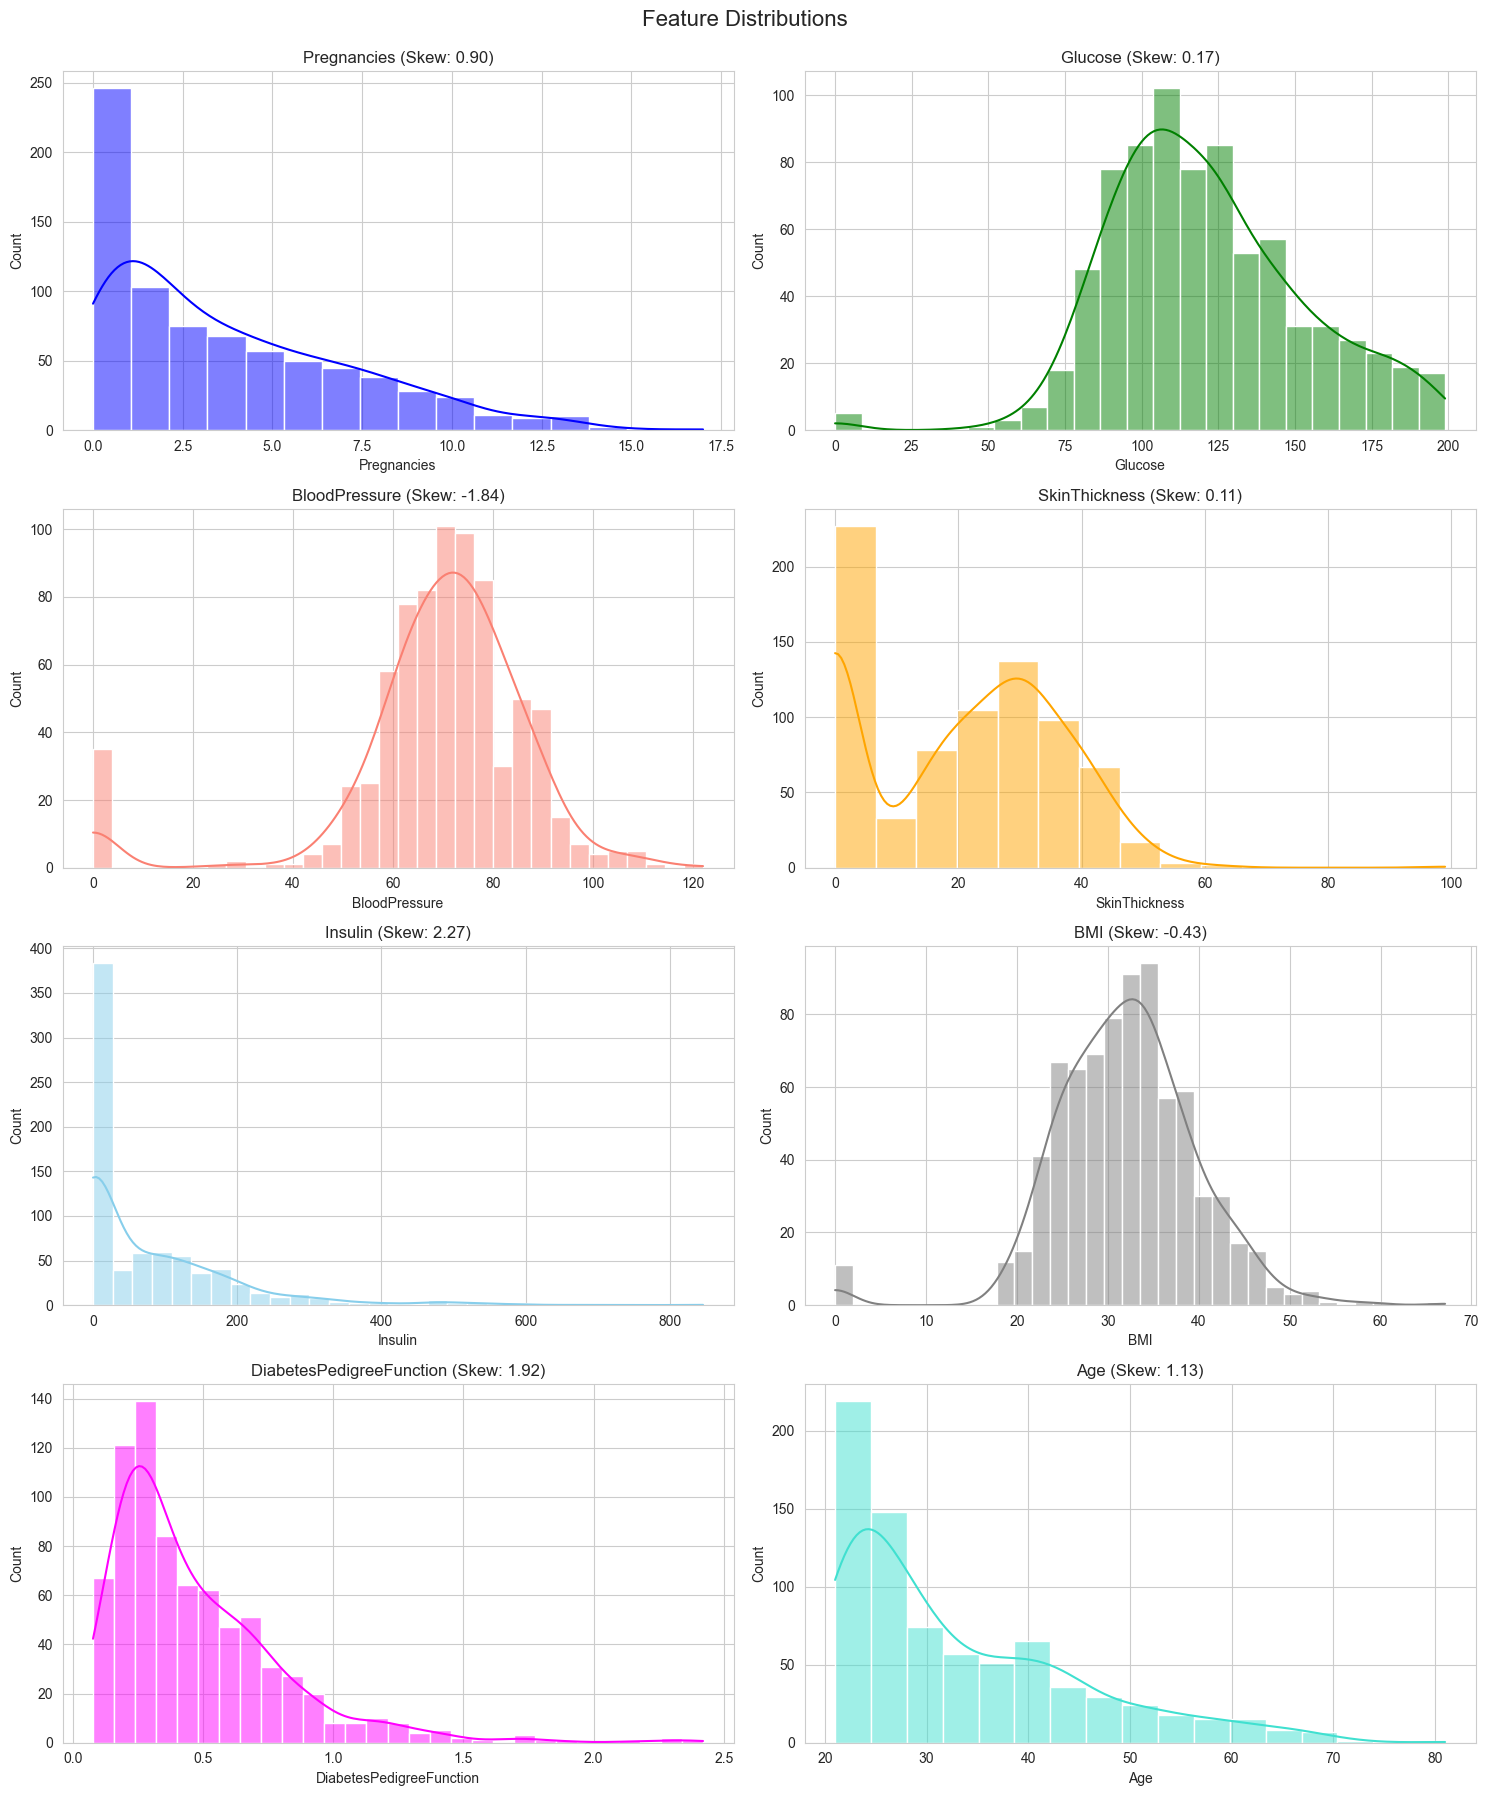

In [9]:
#List of feature coulmns
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

colors = ['blue', 'green', 'salmon', 'orange', 'skyblue', 'grey', 'magenta', 'turquoise']
  
plt.figure(figsize=(15,18))

for i, columns in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[columns], kde=True, color=colors[i-1])
    plt.title(f"{columns} (Skew: {df[columns].skew():.2f})")

plt.suptitle('Feature Distributions', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

##### **Histogram plot Analysis:**

- Most features are skewed to the right, including:
    - Pregnancies(Skew: 0.90)
    - Glucose(Skew: 0.17)
    - Insulin (strongly: 2.27)
    - SkinThickness(Skew: 0.11)
    - Age(Skew: 1.13)
    - Diabetes Pedigree Function(Skew: 1.92)
  
- BloodPressure is closer to a normal distribution, while BMI is fairly balanced.

- Glucose shows some high values (outliers) along with a mild right skew.

- SkinThickness and Insulin contain many zero values, indicating missing or invalid data.

- Pregnancies, Glucose, Age, and Insulin also have a few extreme values.


##### **ii. Bar plot**

Bar plot is done to visualize the distribution of outcome classes, which helps in understanding the balance between diabetes(1) and non-diabetes(0) individuals. The bar plot also helps in identifying whether the dataset is imbalanced.

Outcome
0    500
1    268
Name: count, dtype: int64


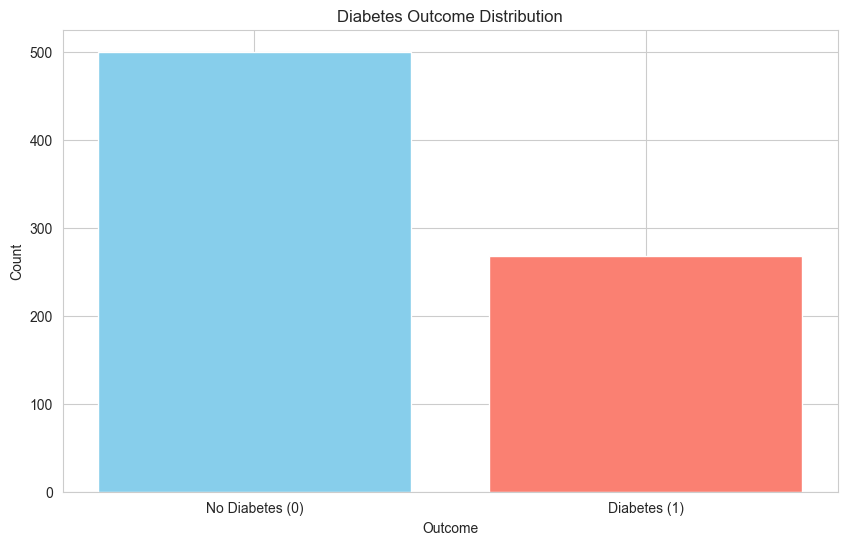

In [10]:
# Check how many people have diabetic and non-diabetic
counts = df['Outcome'].value_counts()
print(counts)

# bar plot to see class imbalance
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])

plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Diabetes Outcome Distribution")
plt.show()


##### **Bar-plot Analysis:**

- There are more non-diabetic people (500) than diabetic people (268), showing a class imbalance.

- This is roughly a 65:35 split(2:1 ratio).

- The imbalance may make the model favor the majority class, so class_weight = 'balanced' will be used in models to fix this.

##### **iii. Box-plot**

Box-plot are used to examine each features distributions, detect outliers and identify extreme values that might impact model's perfromance.


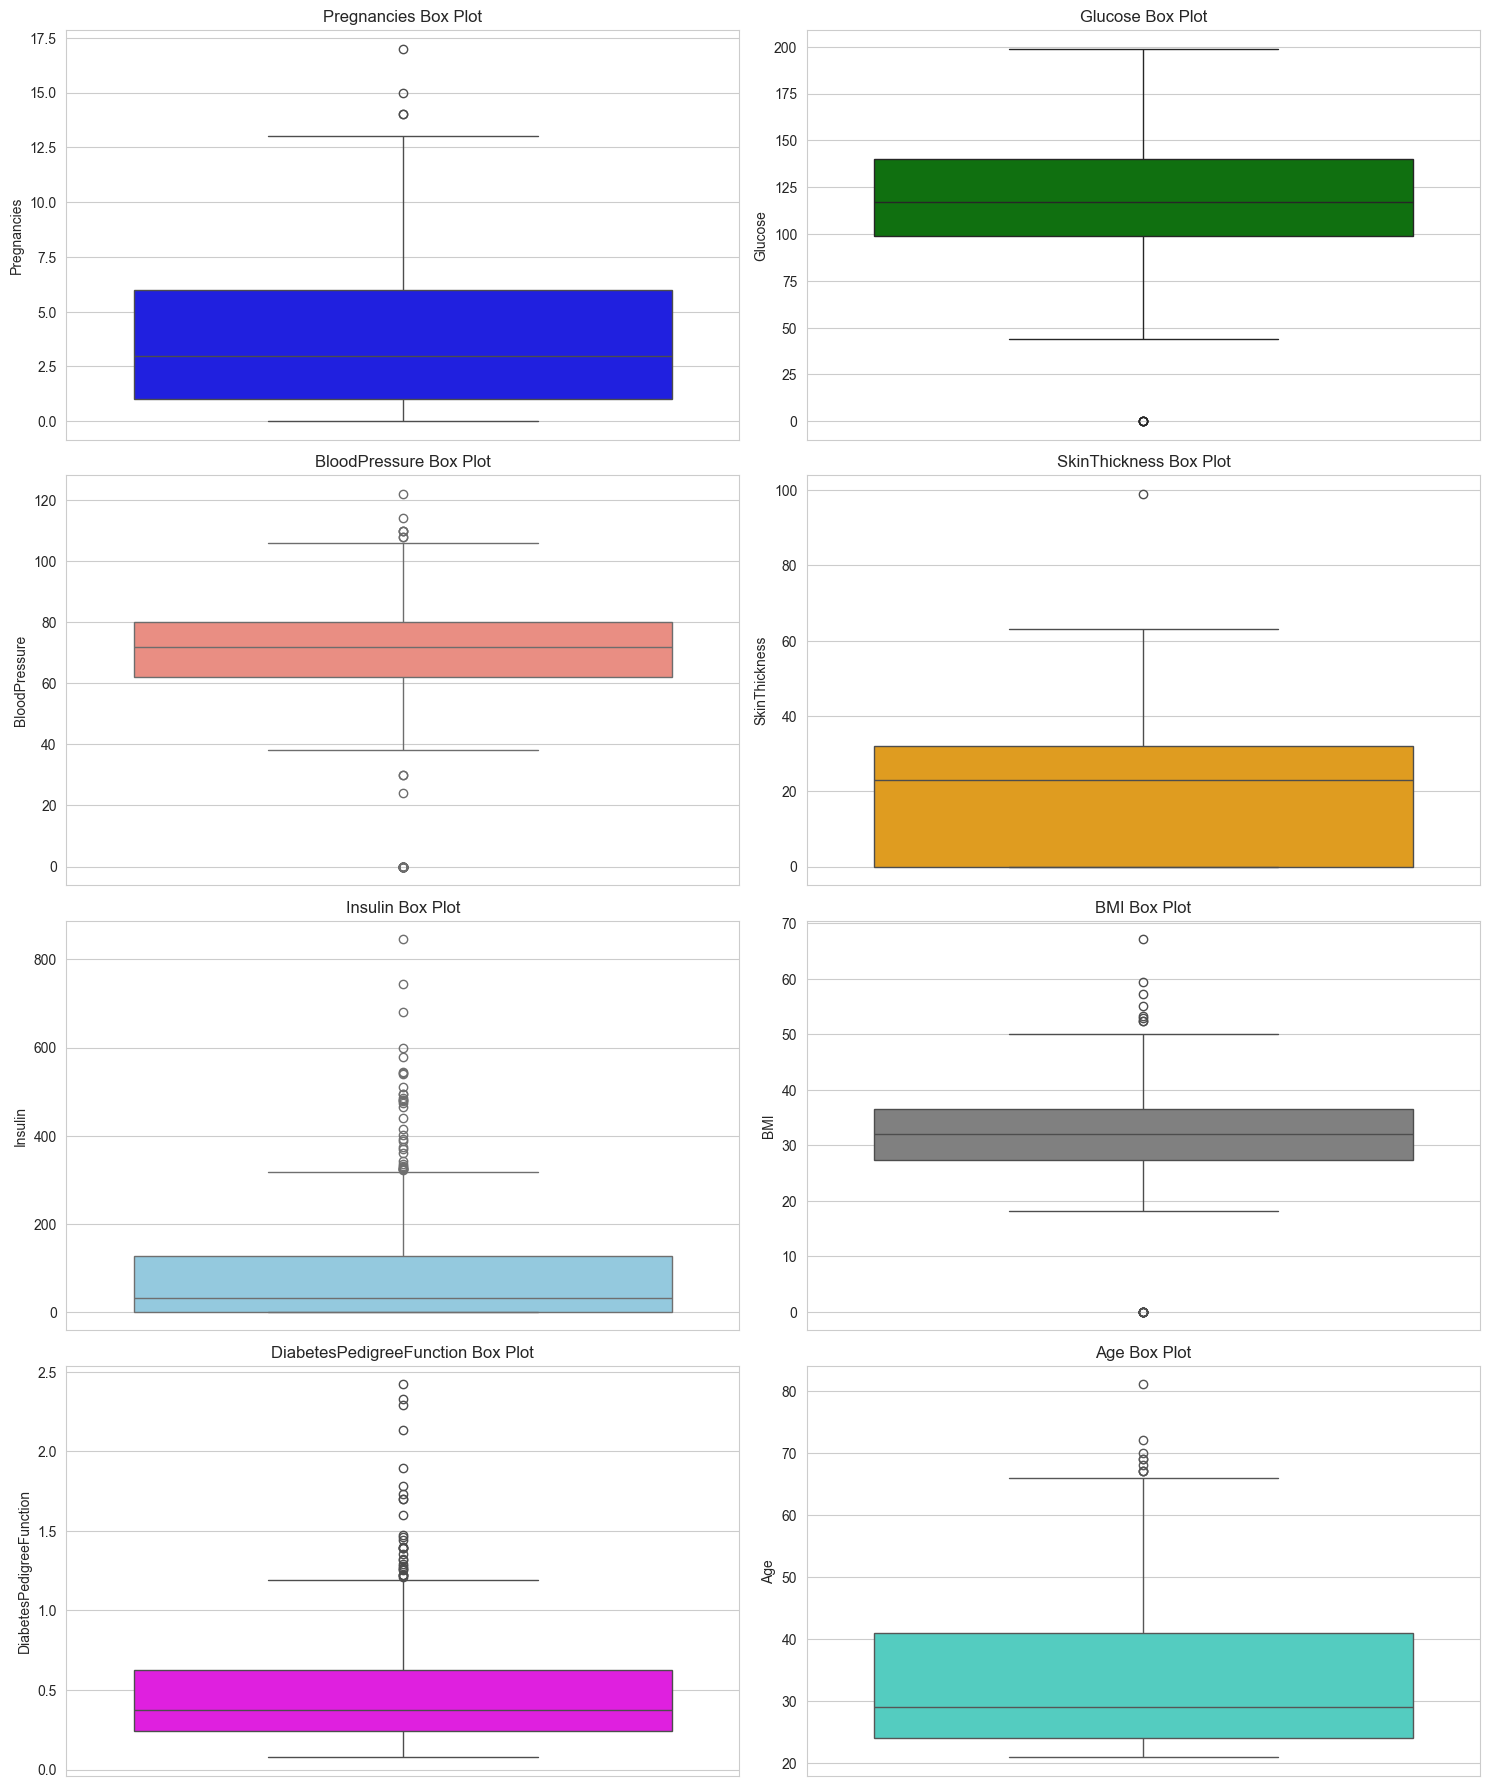

In [11]:
# Box plot to detect outliers
plt.figure(figsize=(15,18))

for i, col in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(y=df[col], color=colors[i-1])
    plt.title(f"{col} Box Plot")

plt.tight_layout()
plt.show()


##### **Box-plot Analysis:**

- Features like Glucose, Insulin, Pregnancies, and Age have several high-value outliers.

- SkinThickness and Insulin show many zero values, indicating  missing or invalid values.

- BloodPressure is fairly consistent with fewer extreme values, indicating a more normal distribution.

- BMI has mild outliers but mostly stays within typical ranges.


##### **II.  Bivariate Analysis**

- It analyzes the relationship between two variables simultaneously.
- It helps to identify associations, differences between groups, and potential correlations.



##### **II.1. Box-plot**

Below boxplots displays each feature for non-diabetic (0) and diabetic (1) patients, showing minimum, 25th percentile, median, 75th percentile, and maximum values. This helps compare feature distributions and find outliers, showing how features differ between diabetic and non-diabetic people.


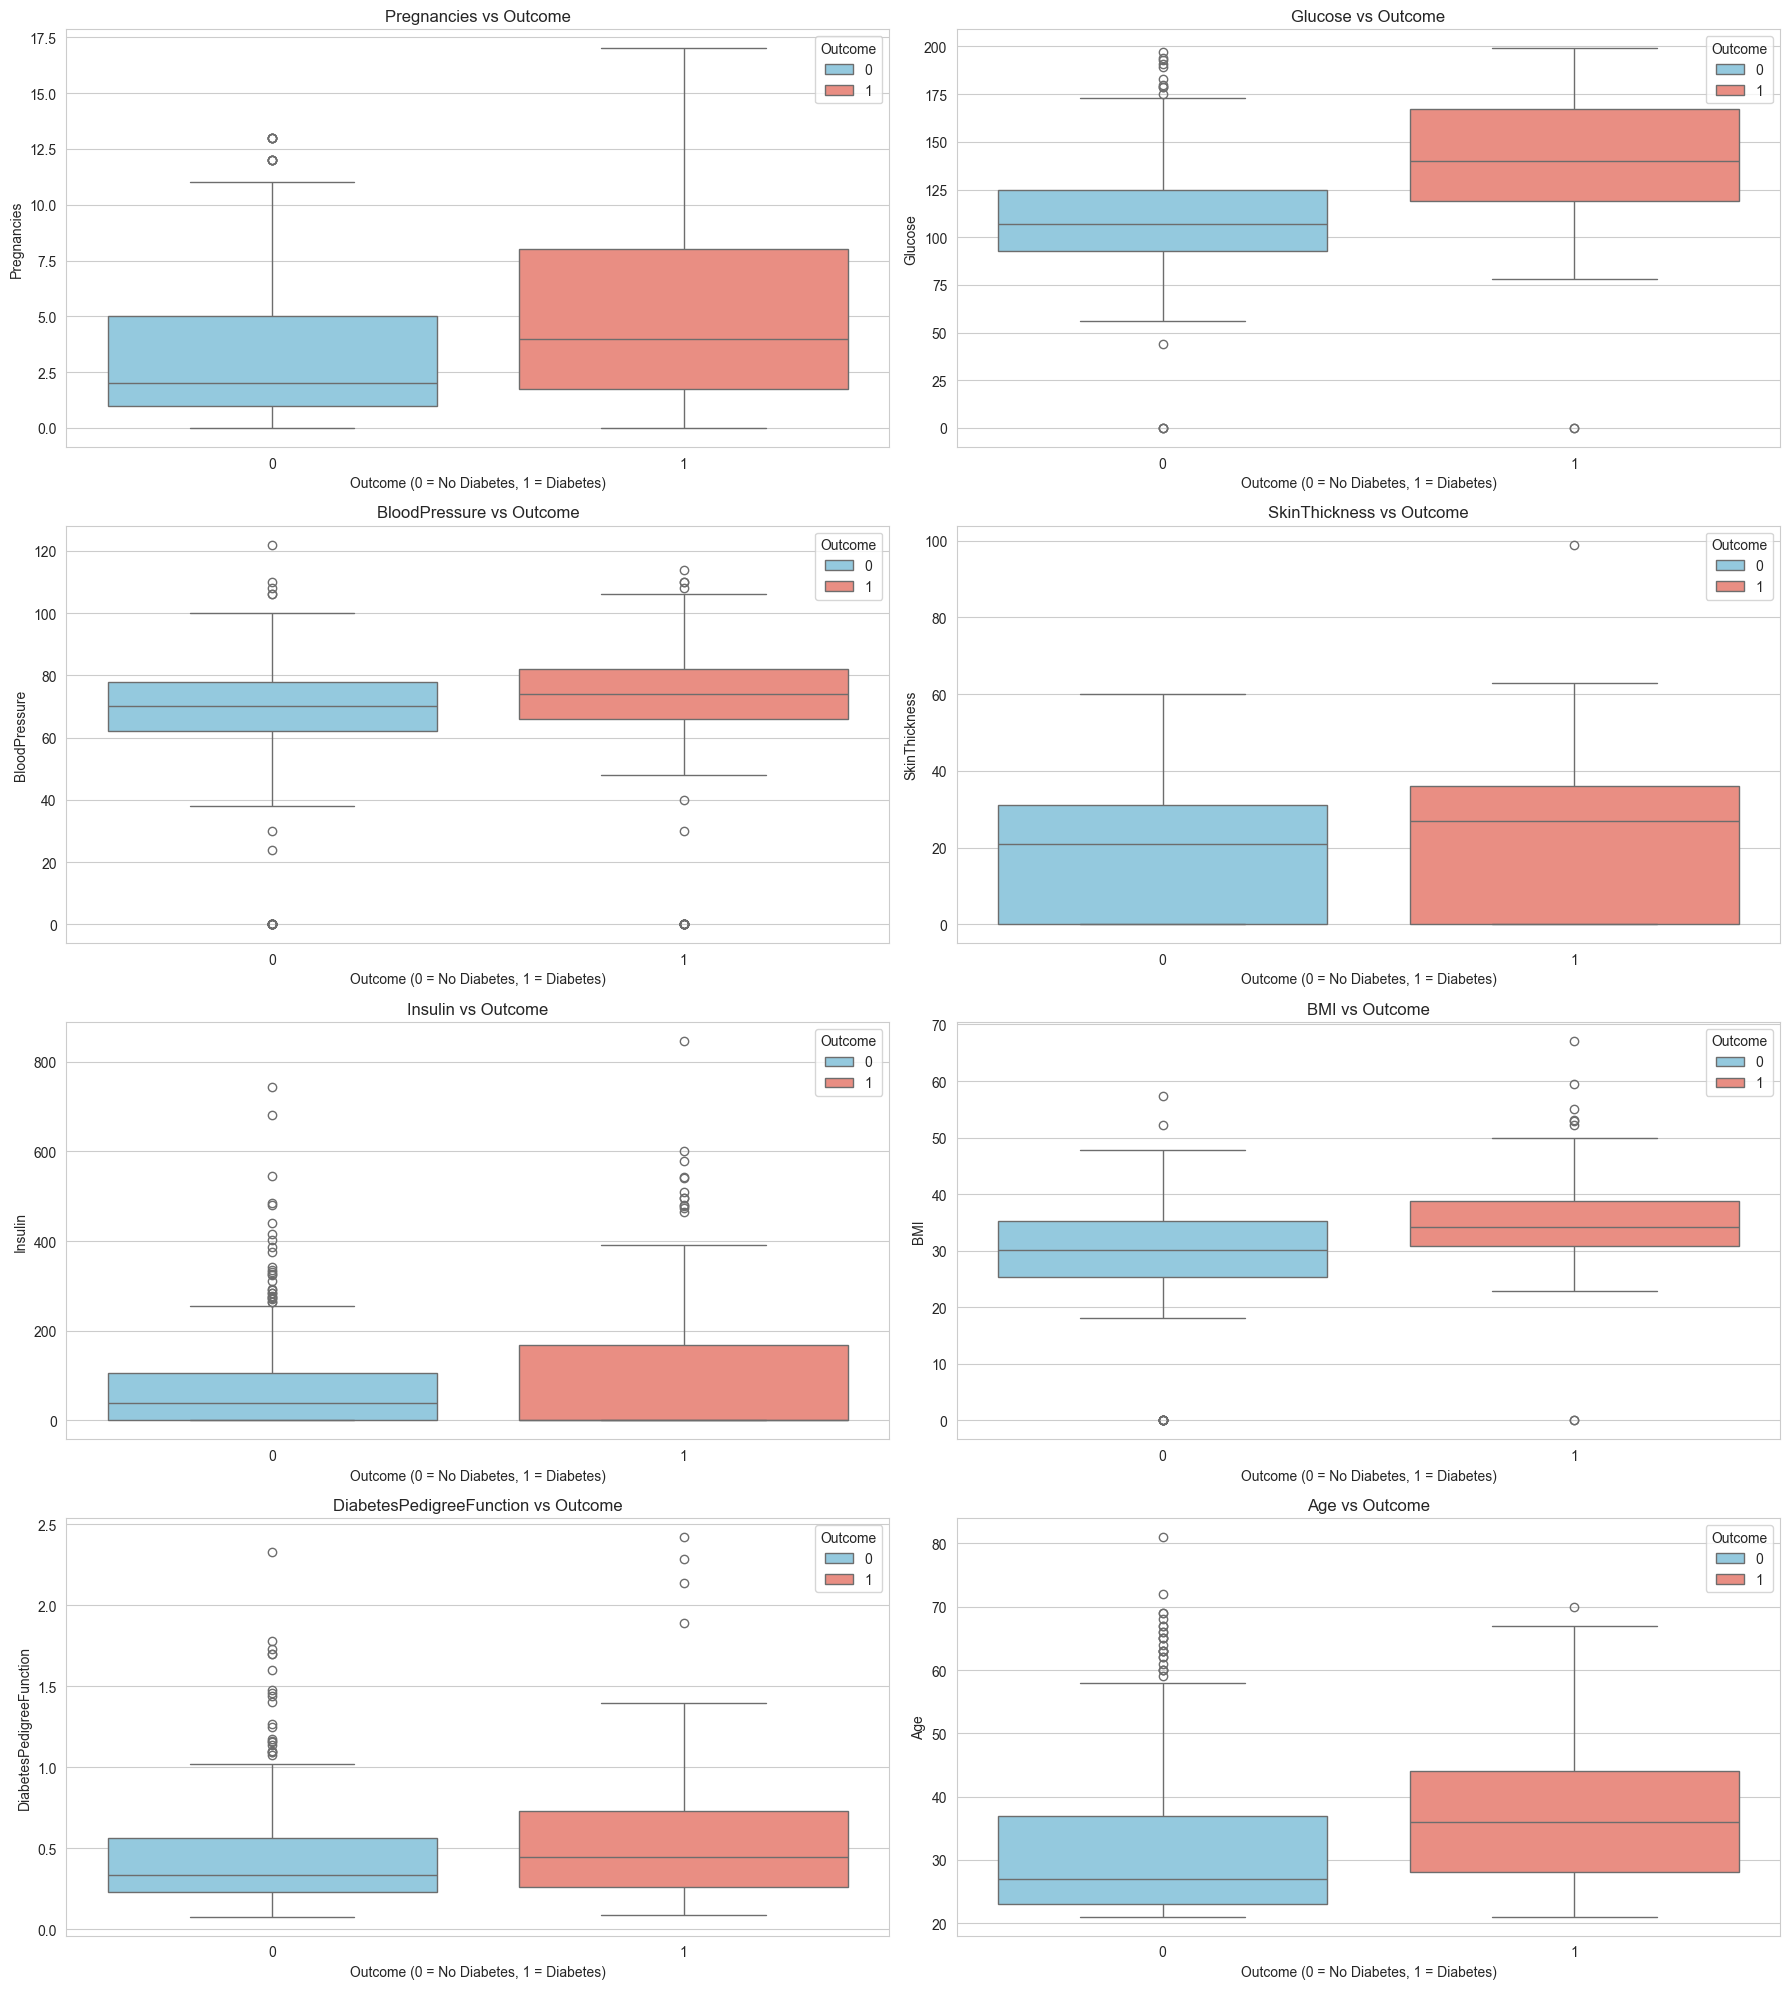

In [12]:
#List of feature columns
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

plt.figure(figsize=(18,20))  

for i, columns in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x='Outcome', y=columns, data=df, hue='Outcome', palette=['skyblue','salmon'], legend=True)
    plt.title(f"{columns} vs Outcome")
    plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
    plt.ylabel(columns)

plt.tight_layout()
plt.show()


##### **Box-plot Analysis:**

- Glucose is much higher in diabetic patients and is the strongest predictor.

- BMI and Age are also higher in diabetics, making them good indicators.

- Pregnancies: More pregnancies slightly increase diabetes risk.

- Blood Pressure, skin thickness, insulin and diabetes pedigree function are slightly higher in diabetic parients but overlap with non-diabetics.

- All features have some outliers (extreme values).

- Overall, Glucose, BMI and Age are the most important indicators for diabetes.

#### **II.2. Correlation heatmap**

The heatmap shows how each feature is related to others and to diabetes. It helps identify which features are strongly connected to diabetes and how the features interact with each other.

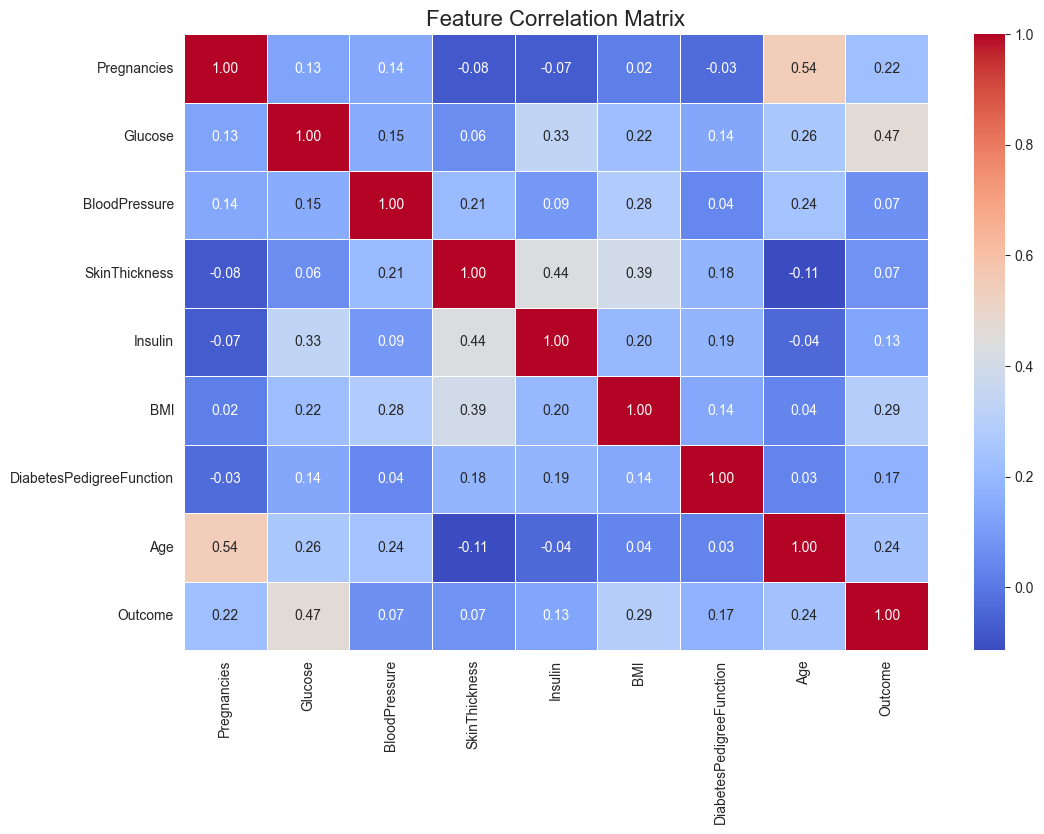

In [13]:
plt.figure(figsize = (12,8))
#Calculate correlation matrix of the dataset
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Feature Correlation Matrix', fontsize = 16)
plt.show()

##### **Correlation heatmap Analysis:**

- **Strong predictor:** Glucose (0.47) is most strongly correlated with diabetes.

- **Moderate predictors:** BMI(0.29), Age(0.24) and Pregnancies(0.22) are moderate predictors.

- **Weak predictors:** BloodPressure, SkinThickness, and Insulin have weak correlations.

- **Feature relationships:** BMI and SkinThickness are moderately correlated (0.39), while most other features have low correlation with each other.

- **No major multicollinearity:** No pair of features shows extremely high correlation(>0.8), so most features are independent.

# **5.  Data pre-processing**

Data pre-processing is done to handle missing data that have been seen as zero values in the dataset. Some features like Glucose, BMI, SkinThickness, Insulin, and BloodPressure have zero values that are not possible in real life.

#### **5.1.Data Cleaning and Imputation**

This step involves cleaning the dataset by handling missing or incorrect values to avoid biasness and to make it suitable for analysis and modeling.


##### **1. Checking for Invalid Zero Values**

The selected feature columns are examined for zero values that are considered invalid. A count of these zeros is displayed, and a heatmap is used to visualize their distribution before cleaning.


Zeros before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


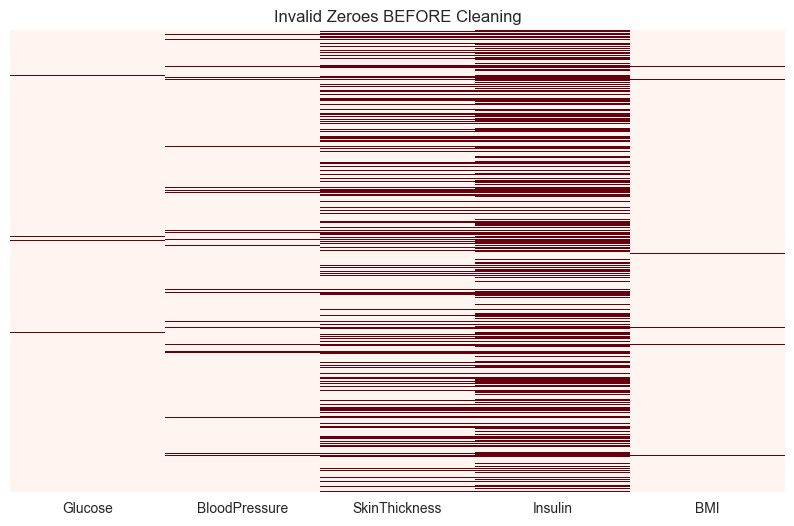

In [14]:
# Columns with an invalid zero value
columns_to_clean = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Count zeros
print("Zeros before cleaning:")
print((df[columns_to_clean]==0).sum())

sns.heatmap(df[columns_to_clean]==0, cmap='Reds', cbar=False, yticklabels = False)
plt.title("Invalid Zeroes BEFORE Cleaning")
plt.show()


##### **2. Handling Invalid Zeroes**

Invalid zero values in selected columns are replaced with NaN, and then missing values are filled using the median. The median is used because it is not affected by outliers and is ideal for skewed data.  

This process improves data quality and ensures models can learn better patterns. Heatmaps and counts before and after cleaning confirm that all invalid zeros and missing values have been handled successfully.


In [15]:
# Replaces 0 with NaN 
df[columns_to_clean] = df[columns_to_clean].replace(0, np.nan)

print("After replacing 0 with NaN:")
print(df[columns_to_clean].isnull().sum())


After replacing 0 with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


AFTER CLEANING - Invalid zeros and missing values:
Zeros remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

NaN remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


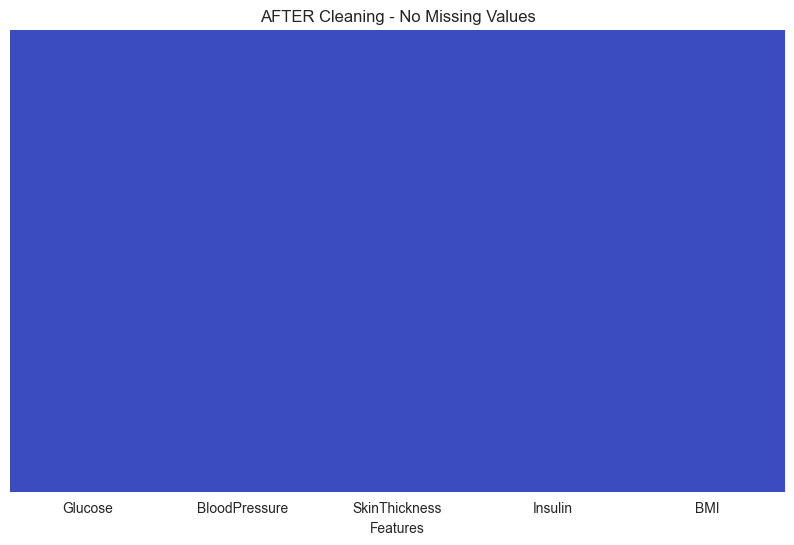

In [16]:
# Fill NaN with median
df[columns_to_clean] = df[columns_to_clean].fillna(df[columns_to_clean].median())

print("AFTER CLEANING - Invalid zeros and missing values:")
print("Zeros remaining:")
print((df[columns_to_clean] == 0).sum())
print("\nNaN remaining:")
print(df[columns_to_clean].isnull().sum())

# heatmap after cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df[columns_to_clean].isnull(), cmap='coolwarm', cbar=False, yticklabels=False)
plt.title('AFTER Cleaning - No Missing Values')
plt.xlabel('Features')
plt.show()

##### **3. Removing Outliers**

Outliers are extreme values that can affect model accuracy. Here, unusually high values in key features were removed to clean the dataset.

In [17]:
# Show original dataset size
print(f"Original dataset size: {len(df)}\n")

# Maximum allowed values for features 
thresholds = {
    'Pregnancies': 15,
    'Insulin': 700,
    'SkinThickness': 80,
    'BMI': 60,
    'DiabetesPedigreeFunction': 2.0
}

# Remove rows with values above thresholds
for feature, max_val in thresholds.items():
    count_removed = (df[feature] > max_val).sum()
    df = df[df[feature] <= max_val]
    print(f"Removed {count_removed} samples where {feature} > {max_val}")

# Show final dataset size and class distribution
print(f"\nFinal dataset size: {len(df)}")
print("Remaining samples per class:")
print(df['Outcome'].value_counts())


Original dataset size: 768

Removed 1 samples where Pregnancies > 15
Removed 2 samples where Insulin > 700
Removed 1 samples where SkinThickness > 80
Removed 1 samples where BMI > 60
Removed 3 samples where DiabetesPedigreeFunction > 2.0

Final dataset size: 760
Remaining samples per class:
Outcome
0    499
1    261
Name: count, dtype: int64


##### **Pre-processing observation:**

- All invalid zeros in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were replaced with median values. 

- Very high values (outliers) were removed: Pregnancies over 15, Insulin over 700, SkinThickness over 80, BMI over 60,and DiabetesPedigreeFunction over 2.0 to keep the data clean.  

- Only 8 samples removed (~1%), keeping most data and class balance intact.

- After this, there are no missing values left in the dataset.

In [18]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

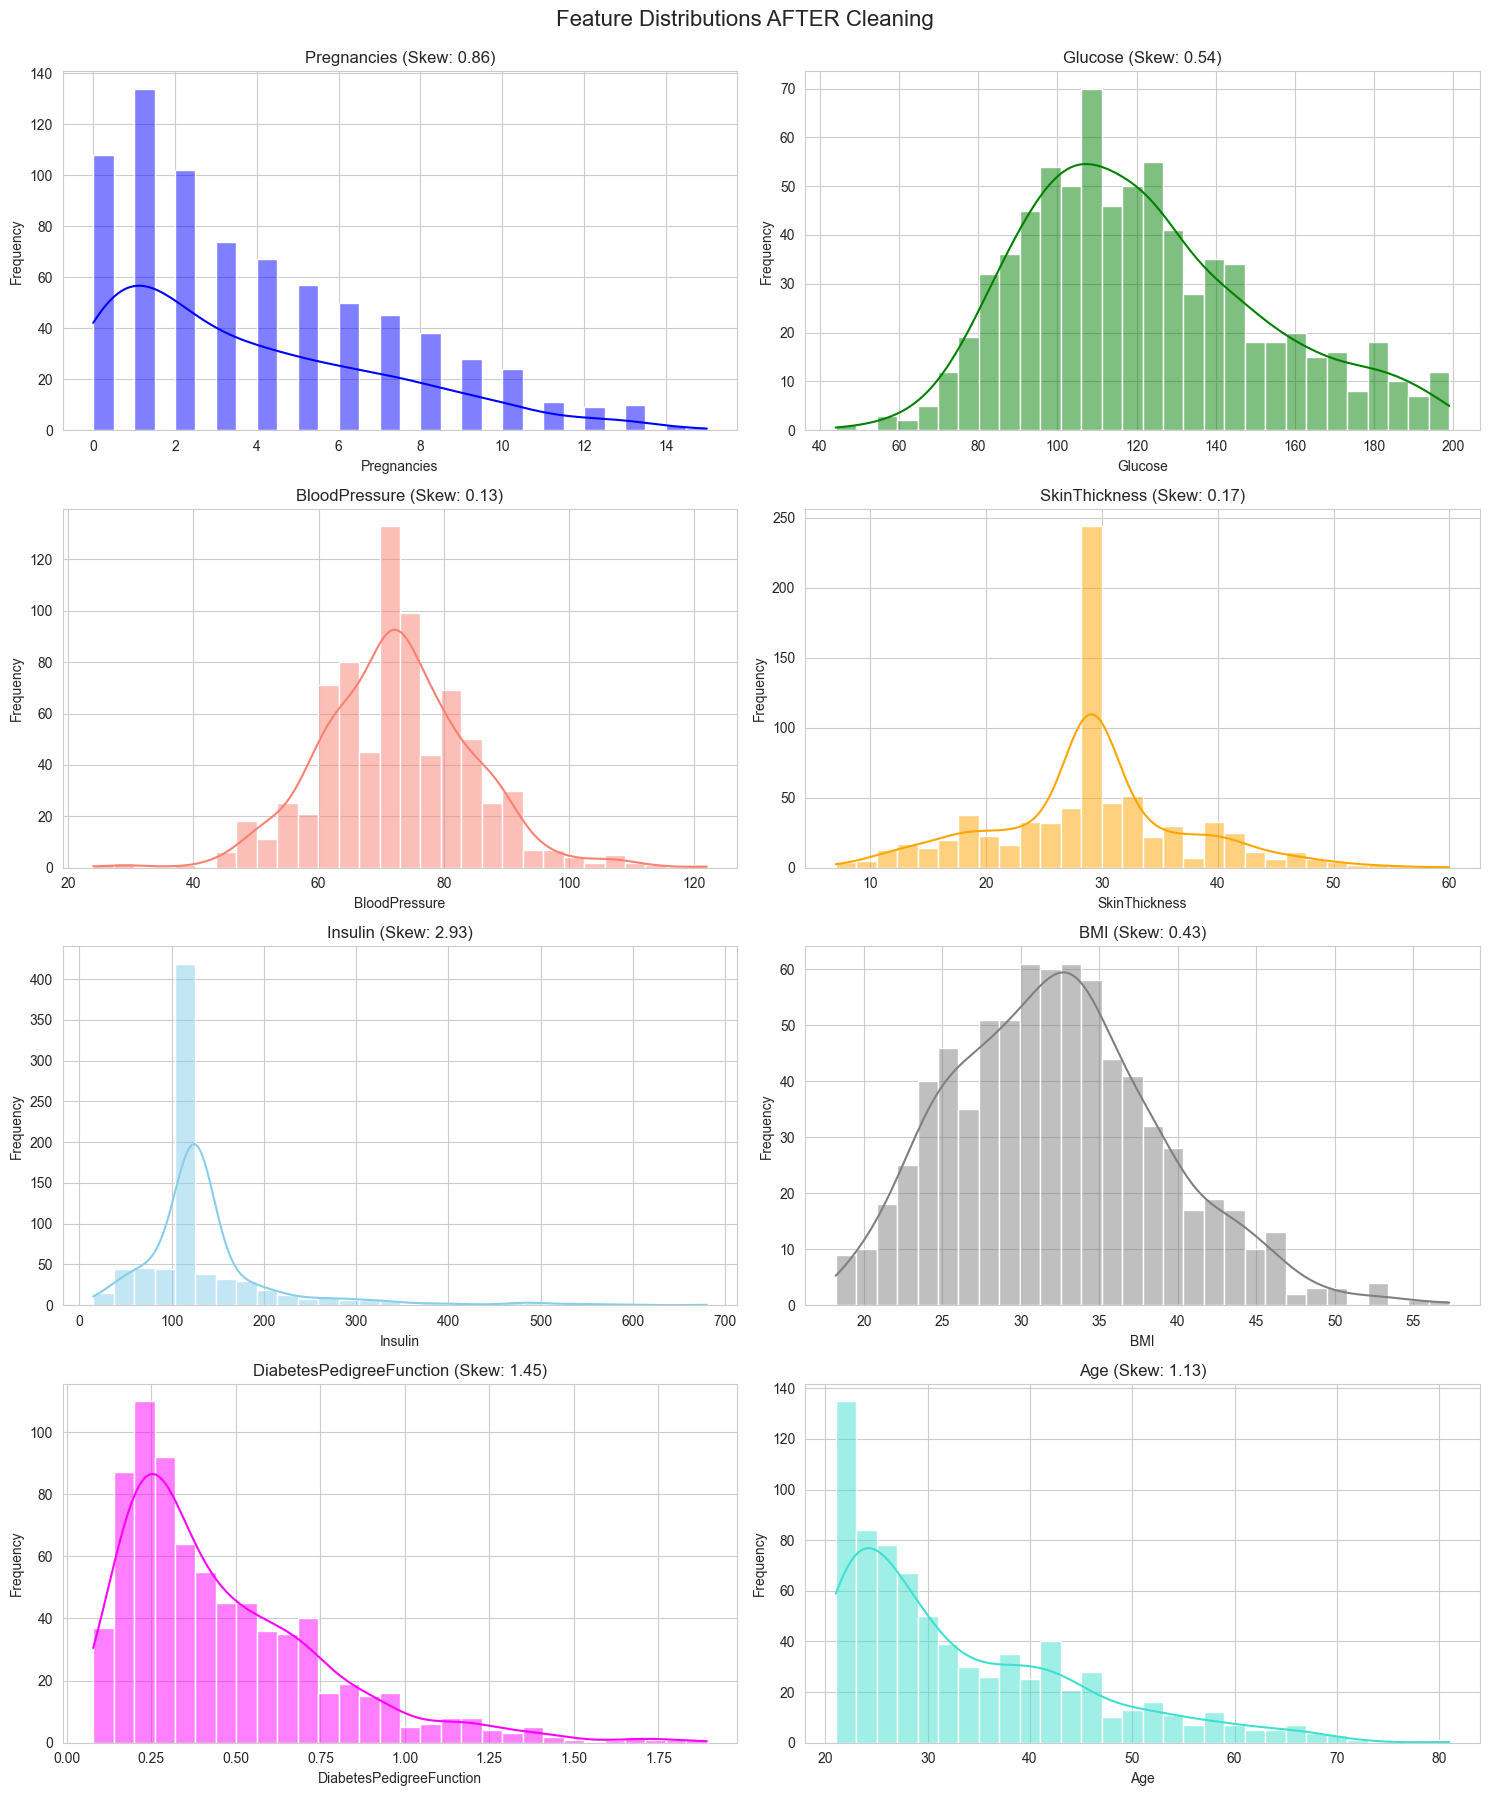

In [19]:
# List of feature columns
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']
colors = ['blue', 'green', 'salmon', 'orange', 'skyblue', 'grey', 'magenta', 'turquoise']

# histogram plots after cleaning
plt.figure(figsize=(15,18))
for i, column in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[column], kde=True, color=colors[i-1], bins=30)
    plt.title(f"{column} (Skew: {df[column].skew():.2f})")
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.suptitle('Feature Distributions AFTER Cleaning', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

##### **Histogram plot Analysis after cleaning:**

- Most features are still slightly right-skewed, but extreme values and zeros have been handled.
      
- Glucose, Insulin, and SkinThickness no longer have zeros, and extreme outliers have been removed.

- BloodPressure looks nearly normal(Skew: 0.13), and BMI is more balanced(Skew: 0.43).

- Outliers have been removed, so the data is cleaner and ready for modeling.

- StandardScaler will still be used later to make all features comparable.


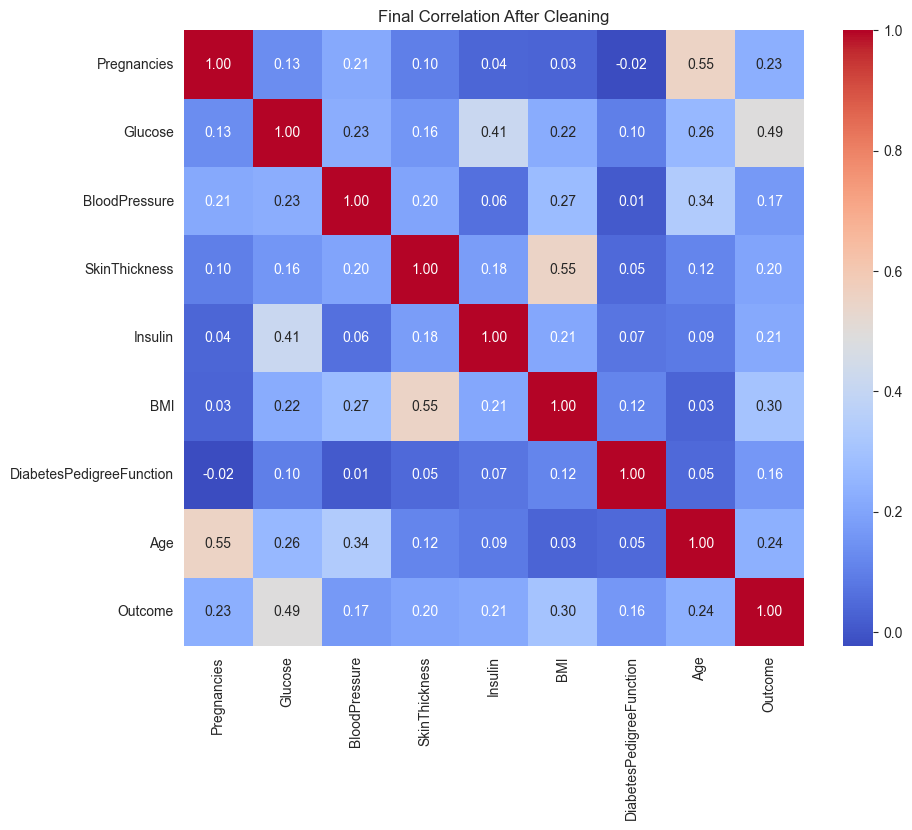

Top predictors:
Outcome                     1.000
Glucose                     0.489
BMI                         0.302
Age                         0.236
Pregnancies                 0.229
Insulin                     0.213
SkinThickness               0.199
BloodPressure               0.168
DiabetesPedigreeFunction    0.164
Name: Outcome, dtype: float64


In [20]:
# Final correlation after cleaning

plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Final Correlation After Cleaning')
plt.show()

print("Top predictors:")
print(df.corr()['Outcome'].sort_values(ascending = False).round(3))

##### **Correlation Analysis after cleaning:**

- Glucose remains the strongest predictor (correlation = 0.493, increased from 0.47)

- BMI(0.312), Age(0.238), and Pregnancies(0.222) also show strong positive relationships with diabetes.

- Insulin correlation improved from 0.13 to 0.20 after imputation, confirming the value of missing data treatment

- There is no multicollinearity as all feature to feature correlations is less than 0.8 ensuring model stability.

#### **5.2. Splitting the datasets into training and testing datasets.**
The dataset is divided into training and testing sets using the `train_test_split()` method.

This allows the model to learn patterns from the training data while checking its performance on the testing data, giving a better idea of how it will work on new, unseen data.

In [21]:
#Features and target
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

#Splitting data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (608, 8)
Testing set shape: (152, 8)


##### **Train-test split observation:**
- The dataset is split into 608 training samples and 152 testing samples (80:20 split).
  
- Using stratify = y keeps the same distribution of diabetic and non-diabetic cases in both training and testing sets. This helps avoid bias and makes model evaluation more reliable

#### **5.3. Feature Scaling**

Feature scaling is done to make all features comparable, since some features (like Glucose) have much larger ranges than others, which can affect certain models.

StandardScaler is used to transform each feature so it has a mean of 0 and standard deviation of 1:

```
scaled_value = (original_value - mean) / standard_deviation
```


# 6. Model Evaluation and Selection



## Model 1: Support Vector Machine(SVM)
SVM is a powerful supervised learning algorithm that finds the optimal hyperplane to seperate different classes by maximizing the margin between them. It performs well on both linear and non-linear data depending on the kernel used.

Two SVM  kernels are evaluated and the best one is selected:

1. **Radial Basis Function(RBF):** It is suitable for non-linear data. it transforms features into a higher-dimensional space to learn complex boundaries.
   
2. **Polynomial:** It is useful when class separation follows polynomial patterns. It models non-linear relationships efficiently.

The best model is chosen based on evaluation metrics, not just the kernel type.

### 1.1 SVM with RBF Kernel
An SVM model with an RBF kernel was built using a pipeline that includes StandardScaler and SVC. The RBF kernel was useful because the diabetic and non-diabetic cases cannot be separated by a straight line and it allows the model to create curved boundaries to better separate the classes.

In [22]:
# RBF kernel pipeline
pipe_rbf = Pipeline([('scaler',
                      StandardScaler()),
                     ('svm', SVC(kernel='rbf', class_weight = 'balanced', random_state = 42))])

#Train svm model
pipe_rbf.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [23]:
#make predictions on the testing data
y_pred = pipe_rbf.predict(X_test) 
print(y_pred)

[0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 1 0 0
 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 0 1
 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0
 1 1 0 0]


In [24]:
# Scores
train_score_rbf = pipe_rbf.score(X_train, y_train)
test_score_rbf = pipe_rbf.score(X_test, y_test)

print("SVM RBF Kernel - Default Parameters:")
print(f"Training Accuracy: {train_score_rbf:.4f}")
print(f"Testing Accuracy: {test_score_rbf:.4f}")

SVM RBF Kernel - Default Parameters:
Training Accuracy: 0.8240
Testing Accuracy: 0.7763


In [25]:
# check for overfitting
performance_gap = train_score_rbf - test_score_rbf

print("Train Accuracy:", train_score_rbf)
print("Test Accuracy :", test_score_rbf)
print("Gap:", performance_gap)

if performance_gap > 0.10: 
    print("\nResult: The model is OVERFITTING.")
else:
    print("\nResult: The model is NOT overfitting.")


Train Accuracy: 0.8240131578947368
Test Accuracy : 0.7763157894736842
Gap: 0.047697368421052655

Result: The model is NOT overfitting.


In [26]:
print("\nClassification Report - SVM RBF Kernel:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Diabetes', 'Diabetes']))


Classification Report - SVM RBF Kernel:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.75      0.82       100
    Diabetes       0.63      0.83      0.72        52

    accuracy                           0.78       152
   macro avg       0.76      0.79      0.77       152
weighted avg       0.80      0.78      0.78       152



##### **RBF Kernel observation:**

- The model achieved **82.4% accuracy on the training data** and **77.6% on the testing data**, with a small **4.8% difference**, indicating that it is not overfitting.

  
- Using class_weight='balanced' helps handle class imbalance so that model pays more attention to diabetic cases since they are fewer in the dataset(268).

- Class-wise performance:

    * **No Diabetes(0):** Precision = 89%, Recall = 75%, F1-score = 82%

    * **Diabetes(1):** Precision = 63%, Recall = 83%, F1-score = 72%

- High recall for diabetes (83%) shows the model effectively identifies diabetic patients.

The model works reasonably well but can be improved by tuning C and gamma to achieve a smoother and more generalizable decision boundary.


### 1.2. SVM with Polynomial Kernel
SVM with a Polynomial kernel is used to capture polynomial relationships in the data. The model is built using a pipeline that includes StandardScaler and SVC, since SVM is sensitive to feature scales.

The Polynomial kernel is useful when class separation follows polynomial patterns rather than simple linear boundaries.

In [27]:
# Polynomial kernel pipeline
pipe_poly = Pipeline([('scaler', 
                       StandardScaler()),
                      ('svm', SVC(kernel='poly', class_weight='balanced', random_state = 42 ))])

# Train model
pipe_poly.fit(X_train, y_train)



,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'


In [28]:
# Make predictions
y_pred_poly = pipe_poly.predict(X_test)
print(y_pred_poly)

[0 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0
 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1
 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 1 0 0]


In [29]:
# Scores
train_score_poly = pipe_poly.score(X_train, y_train)
test_score_poly = pipe_poly.score(X_test, y_test)

print("SVM Polynomial Kernel - Default Parameters:")
print(f"Training Accuracy: {train_score_poly:.4f}")
print(f"Testing Accuracy: {test_score_poly:.4f}")


SVM Polynomial Kernel - Default Parameters:
Training Accuracy: 0.8158
Testing Accuracy: 0.7500


In [30]:
# check for overfitting
performance_gap_poly = train_score_poly - test_score_poly

print("Train Accuracy:", train_score_poly)
print("Test Accuracy :", test_score_poly)
print("Gap:", performance_gap_poly)

if performance_gap_poly > 0.05:   
    print("\nResult: The model is OVERFITTING.")
else:
    print("\nResult: The model is NOT overfitting.")


Train Accuracy: 0.8157894736842105
Test Accuracy : 0.75
Gap: 0.06578947368421051

Result: The model is OVERFITTING.


In [31]:
print("\nClassification Report - SVM Polynomial Kernel:")
print(classification_report(y_test, y_pred_poly, 
                          target_names=['No Diabetes', 'Diabetes']))


Classification Report - SVM Polynomial Kernel:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.65      0.60      0.62        52

    accuracy                           0.75       152
   macro avg       0.72      0.71      0.72       152
weighted avg       0.75      0.75      0.75       152



##### **Polynomial Kernel observation:**

- The model achieved about **81.5% accuracy on the training data** and **75% on the testing data**, resulting in a noticeable performance gap of around **6.6%**, which indicates overfitting.

- Class-wise performance shows that the model predicts non-diabetic (0) cases well, with good precision (80%) and recall (83%).

- However, the model performs weaker on diabetic cases (1), with a **recall of only 60%**, meaning it fails to identify a significant number of diabetic patients as well as the **f1-score is 62% only**.

- This lower recall for diabetes is risky in a medical context, as missing positive cases is more harmful than false alarms.

Overall, the Polynomial kernel struggles to balance both classes effectively and performs worse for diabetic case detection compared to the RBF kernel, which achieves higher recall and f1-score for diabetes.


### 2. SELECTING BEST SVM KERNEL
RBF and Polynomial kernels are evaluated on the test set using metrics like accuracy, precision, recall, and F1-score. The best kernel is selected by comparing the F1-score, as it balances precision and recall and is especially important for detecting diabetic cases.


In [32]:
# Choose the best SVM model
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    }

# Compute metrics 
metrics_rbf = compute_metrics(pipe_rbf, X_test, y_test)
metrics_poly = compute_metrics(pipe_poly, X_test, y_test)

# Select best kernel by F1-Score
if metrics_rbf['F1-Score'] >= metrics_poly['F1-Score']:
    best_kernel = 'RBF'
    best_metrics = metrics_rbf
else:
    best_kernel = 'Polynomial'
    best_metrics = metrics_poly

print(f"BEST SVM KERNEL SELECTED: {best_kernel}")
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.4f}")


BEST SVM KERNEL SELECTED: RBF
Accuracy: 0.7763
Precision: 0.6324
Recall: 0.8269
F1-Score: 0.7167


### **Justification for Selecting the Best SVM Kernel**

- Both RBF and Polynomial kernels were evaluated on the test dataset using accuracy, precision, recall, and F1-score.

- Although the overall testing accuracy of both kernels is similar **(RBF = 77.6% and Polynomial = 75%)**, the RBF kernel performs better in identifying diabetic cases.

- The RBF kernel achieved a higher **recall (82.7%)**, meaning it correctly identifies most diabetic patients and misses fewer positive cases compared to the Polynomial kernel.

- It also obtained a higher **F1-score (71.7%)**, showing a better balance between precision and recall for the diabetic class.

- The Polynomial kernel, on the other hand, shows lower **recall (60%) and F1-score (62%)** for diabetes, indicating weaker performance in detecting positive cases.

- In medical datasets, recall is more important than accuracy because failing to detect a disease can have serious consequences.

**Conclusion:**  
The RBF kernel is selected as the best SVM model because it provides better detection of diabetic cases and a stronger balance between precision and recall, making it more suitable for diabetes prediction.


## 6.1. Hyperparameter tuning
Hyperparameter tuning is performed using GridSearchCV with k-fold cross-validation to identify parameter values that generalize well to unseen data rather than fitting only the training set. 

Different hyperparameters are tuned for each model based on how they influence model complexity and generalization:

- **SVM (RBF kernel):** C and gamma
- **Random Forest:** n_estimators, max_depth, min_samples_split, min_samples_leaf, and max_features

These parameters directly control the flexibility of the models and help reduce overfitting while maintaining predictive performance.

#### I. Hyperparameter tuning - RBF kernel
The RBF kernel has two main hyperparameters: C and gamma.

- **C(regularization parameter)**: It controls how strict the model is. Higher C fits the training data more closely but may overfit, while lower C allows some mistakes and keeps the model simpler.

- **Gamma:** It decides how much each data point affects the model. A high gamma makes the model more complex, while low gamma makes it smoother and more general.

GridSearchCV with 10-fold cross-validation was used to try different combinations of C and gamma to find the best balance for unseen data.


In [33]:
param_grid_rbf = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

# GridSearchCV with 10-fold cross-validation
grid_rbf = GridSearchCV(pipe_rbf, param_grid_rbf, cv=10, scoring='accuracy', 
                        n_jobs=-1, verbose=1)

# Fit GridSearchCV
print("\nPerforming GridSearchCV for RBF kernel...")
grid_rbf.fit(X_train, y_train)

# Best parameters
print("\nBest parameters for RBF kernel:", grid_rbf.best_params_)
print(f"Best cross-validation score: {grid_rbf.best_score_:.4f}")


Performing GridSearchCV for RBF kernel...
Fitting 10 folds for each of 16 candidates, totalling 160 fits

Best parameters for RBF kernel: {'svm__C': 100, 'svm__gamma': 0.01}
Best cross-validation score: 0.7697


In [34]:
# Use best model
best_pipe_rbf = grid_rbf.best_estimator_
y_pred_rbf_tuned = best_pipe_rbf.predict(X_test)
print(y_pred_rbf_tuned)

# Scores
train_score_rbf_tuned = best_pipe_rbf.score(X_train, y_train)
test_score_rbf_tuned = best_pipe_rbf.score(X_test, y_test)

print(f"\nTuned RBF Model:")
print(f"Training Accuracy: {train_score_rbf_tuned:.4f}")
print(f"Testing Accuracy: {test_score_rbf_tuned:.4f}")

[0 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0
 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 0 1
 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0
 1 1 0 0]

Tuned RBF Model:
Training Accuracy: 0.8076
Testing Accuracy: 0.7763


In [35]:
# check for overfitting
performance_gap_tuned = train_score_rbf_tuned - test_score_rbf_tuned

print("Train Accuracy:", train_score_rbf_tuned)
print("Test Accuracy :", test_score_rbf_tuned)
print("Gap:", performance_gap_tuned)

if performance_gap_tuned > 0.10:   
    print("\nResult: The model is OVERFITTING.")
else:
    print("\nResult: The model is NOT overfitting.")


Train Accuracy: 0.8075657894736842
Test Accuracy : 0.7763157894736842
Gap: 0.03125

Result: The model is NOT overfitting.


##### **Hyperparametr tuning observation:**
- GridSearchCV selected **C = 100** and **gamma = 0.01**, creating a smoother and more stable decision boundary.

- A total of 16 parameter combinations (4 C × 4 gamma) were tested using 10-fold cross-validation , achieving a best cross-validation score of 0.7697, ensuring good performance on unseen data.

- After tuning, the training accuracy slightly decreased to 80.8%, while testing accuracy remained similar at 77.6%, reducing overfitting (train-test gap: 3.1%).

- The slight drop in training accuracy shows that the tuned model no longer tries to perfectly fit every training point, instead it focuses on generalization to unseen data. 

Overall, hyperparameter tuning intentionally sacrifices a small amount of training performance to achieve better generalization and more reliable predictions on new unseen data.

### RBF Kernel Evaluation
The tuned RBF kernel is evaluated using the confusion matrix and classification report. Accuracy alone is not enough for imbalanced data, so it’s important to also check:

- Recall: How well the model identifies diabetic patients.

- Precision: How reliable the positive predictions are.

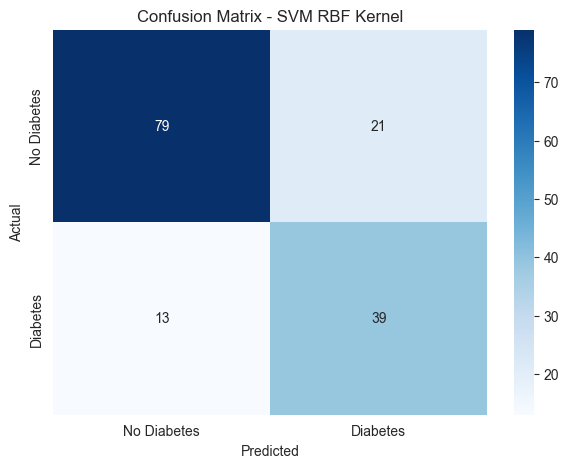

In [36]:
# Confusion Matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.title('Confusion Matrix - SVM RBF Kernel')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

##### **Confusion Matrix Analysis:**
- The model correctly identified 79 people without diabetes (True Negative).

- It wrongly predicted 21 non-diabetic people as diabetic (False Positive).

- It missed 13 diabetic patients, predicting them as non-diabetic (False Negative). This is the most serious error.

- It correctly detected 39 diabetic patients (True Positive).



In [37]:
# Individual metrics
accuracy_rbf = accuracy_score(y_test, y_pred_rbf_tuned)
precision_rbf = precision_score(y_test, y_pred_rbf_tuned)
recall_rbf = recall_score(y_test, y_pred_rbf_tuned)
f1_rbf = f1_score(y_test, y_pred_rbf_tuned)

print(f"\nSVM RBF Kernel - Performance Metrics:")
print(f"Accuracy:  {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall:    {recall_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")


SVM RBF Kernel - Performance Metrics:
Accuracy:  0.7763
Precision: 0.6500
Recall:    0.7500
F1-Score:  0.6964


#### Classification Report

The classification report summarizes the model’s performance by showing precision, recall, F1-score, and accuracy for each class. It provides a detailed view of how well the model predicts diabetic and non-diabetic cases beyond overall accuracy.


In [38]:
print("\nClassification Report - SVM RBF Kernel:")
print(classification_report(y_test, y_pred_rbf_tuned, 
                          target_names=['No Diabetes', 'Diabetes']))


Classification Report - SVM RBF Kernel:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.79      0.82       100
    Diabetes       0.65      0.75      0.70        52

    accuracy                           0.78       152
   macro avg       0.75      0.77      0.76       152
weighted avg       0.79      0.78      0.78       152



##### **Classification Report Analysis:**

After hyperparameter tuning, the SVM RBF kernel shows balanced performance across both classes.

- For **No Diabetes (0)**, the model achieves high precision (86%) and good recall (79%), meaning most non-diabetic cases are correctly identified with few false alarms.

- For **Diabetes (1)**, the model achieves a recall of 75%, indicating it successfully detects most diabetic patients, which is important for medical prediction tasks.

- The F1-score for the diabetic class is 70%, showing a reasonable balance between precision and recall after tuning.

Overall, the tuned model maintains stable accuracy while improving its ability to generalize and consistently identify diabetic cases without overfitting.


## Model 2: Random forest
Random Forest is an ensemble method that combines many decision trees to make predictions. By averaging multiple trees, it reduces overfitting and performs better on new data than a single tree.

#### I. Building random forest model
A Random Forest classifier is first built with default settings to create a baseline. class_weight = 'balanced' is used to handle class imbalance so that diabetic and non-diabetic cases are treated equally during training.

In [39]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('rf', RandomForestClassifier(
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        max_features='sqrt'
    ))
])
# Train model
rf_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,5


##### **Random Forest Model Constraints:**

- **max_depth = 5:** Keeps trees shallow so the model does not become too complex.
- **min_samples_split = 5:** A node is split only when enough data is available, reducing noise.
- **min_samples_leaf = 4:** Ensures each leaf has enough samples for more stable predictions.
- **max_features = 'sqrt':** Uses a random subset of features to make trees less similar.
- **class_weight = 'balanced':** Gives equal importance to diabetic and non-diabetic cases.
- **random_state = 42:** Keeps results consistent each time the model is run.


In [40]:
# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)
print(y_pred_rf)

[0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 1 0 0
 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1
 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1
 1 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0
 1 1 0 0]


In [41]:
# Scores
train_score_rf = rf_pipeline.score(X_train, y_train)
test_score_rf = rf_pipeline.score(X_test, y_test)

print("Random Forest - Default Parameters:")
print(f"Training Accuracy: {train_score_rf:.4f}")
print(f"Testing Accuracy: {test_score_rf:.4f}")


Random Forest - Default Parameters:
Training Accuracy: 0.8240
Testing Accuracy: 0.7566


In [42]:
# check for overfitting
performance_gap_rf = train_score_rf - test_score_rf

print("Train Accuracy:", train_score_rf)
print("Test Accuracy :", test_score_rf)
print("Gap:", performance_gap_rf)

if performance_gap_rf > 0.10:   
    print("\nResult: The model is OVERFITTING.")
else:
    print("\nResult: The model is NOT overfitting.")


Train Accuracy: 0.8240131578947368
Test Accuracy : 0.756578947368421
Gap: 0.06743421052631582

Result: The model is NOT overfitting.


In [43]:
# Classification Report
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf,
                          target_names=['No Diabetes', 'Diabetes']))



Classification Report - Random Forest:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.74      0.80       100
    Diabetes       0.61      0.79      0.69        52

    accuracy                           0.76       152
   macro avg       0.74      0.76      0.74       152
weighted avg       0.78      0.76      0.76       152



##### **Random Forest Observation:**

- The Random Forest model achieved **82.4% training accuracy** and **75.7% testing accuracy**, with a gap of about **6.7%**, indicating mild overfitting.

- Even though basic constraints such as limited tree depth and minimum sample requirements were applied, the model still fits the training data better than the unseen test data.

- Using **class_weight = 'balanced'** helps the model pay more attention to diabetic cases, which are fewer in number, making the learning process fairer.

- Class-wise performance shows:
  
  * **No Diabetes (0):** Precision = 87%, Recall = 74%, F1-score = 80%  
  * **Diabetes (1):** Precision = 61%, Recall = 79%, F1-score = 69%

- The high recall for diabetes (79%) indicates that the model is effective at identifying diabetic patients, which is especially important in medical prediction tasks.

Overall, the Random Forest model performs well in detecting diabetic cases but still shows signs of overfitting, suggesting that further hyperparameter tuning is needed to improve generalization on unseen data.


#### II.2 Hyperparameter tuning - Random Forest
Even though Random Forest is robust, tuning its parameters helps prevent overfitting and improve performance on new data.

The following hyperparameters are tuned:

- **n_estimators:** Number of trees. A moderate number gives stable predictions without extra computation.
- **max_depth:** Maximum depth of each tree. Smaller depth keeps trees simpler and reduces overfitting.
- **min_samples_split:** Minimum samples needed to split a node. Higher values prevent overly complex trees.
- **min_samples_leaf:** Minimum samples at a leaf. Larger values help the model generalize better.
- **max_features:** Number of features considered for each split. Using a subset reduces tree similarity between trees and improves generalization.

GridSearchCV with 10-fold cross-validation is used to test different combinations and choose the best model for unseen data.

In [44]:
param_grid_rf = {
    'rf__n_estimators': [100, 300, 400],
    'rf__max_depth': [3, 5, 7, 10, 15],
    'rf__min_samples_split': [10, 15, 20],
    'rf__min_samples_leaf': [4, 6, 8],
    'rf__max_features': ['sqrt', 'log2']
}
# GridSearchCV
grid_rf = GridSearchCV(
    rf_pipeline, 
    param_grid_rf, 
    cv=10, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

# Fit GridSearchCV
print("\nPerforming GridSearchCV for Random Forest...")
grid_rf.fit(X_train, y_train)

#  Best parameters
print("\nBest parameters for Random Forest:", grid_rf.best_params_)
print(f"Best cross-validation score: {grid_rf.best_score_:.4f}")



Performing GridSearchCV for Random Forest...
Fitting 10 folds for each of 270 candidates, totalling 2700 fits

Best parameters for Random Forest: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Best cross-validation score: 0.7779


In [45]:
# Use best model
best_rf_pipeline = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
print(y_pred_rf_tuned)

# Scores
train_score_rf_tuned = best_rf_pipeline.score(X_train, y_train)
test_score_rf_tuned = best_rf_pipeline.score(X_test, y_test)
performance_gap_rf = train_score_rf_tuned - test_score_rf_tuned

print(f"\nTuned Random Forest Model:")
print(f"Training Accuracy: {train_score_rf_tuned:.4f}")
print(f"Testing Accuracy:  {test_score_rf_tuned:.4f}")

[0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 1 0 0
 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1
 1 0 0 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0
 1 1 0 0]

Tuned Random Forest Model:
Training Accuracy: 0.8503
Testing Accuracy:  0.7895


In [46]:
# check for overfitting
performance_gap_rf_tuned = train_score_rf_tuned - test_score_rf_tuned

print("Train Accuracy:", train_score_rf_tuned)
print("Test Accuracy :", test_score_rf_tuned)
print("Gap:", performance_gap_rf_tuned)

if performance_gap_rf_tuned > 0.10:   
    print("\nResult: The model is OVERFITTING.")
else:
    print("\nResult: The model is NOT overfitting.")


Train Accuracy: 0.850328947368421
Test Accuracy : 0.7894736842105263
Gap: 0.06085526315789469

Result: The model is NOT overfitting.


##### **Hyperparameter Tuning Observation - Random Forest:**

- GridSearchCV selected the best parameters which create trees that are not too deep and generalize better:

    - max_depth = 10
    
    - min_samples_split = 10
    
    - min_samples_leaf = 8
    
    - n_estimators = 100
    
    - max_features = 'sqrt'  

- After tuning, the **training accuracy slightly decreased from ~82% to 85%** and **testing accuracy improved from 75.67% to ~79%** reducing overfitting.

- The small difference between training and testing accuracy shows the model generalizes well.

- Class-wise performance also improved for diabetic cases, making predictions more reliable.  

Overall, hyperparameter tuning produced a Random Forest model that is stable, generalizes better, and performs well in predicting diabetes.


### Random Forest Evaluation
The tuned Random Forest model is evaluated using multiple metrics. This evaluation shows how accurately the model predicts diabetic cases, balances precision and recall, and generalizes to unseen data.

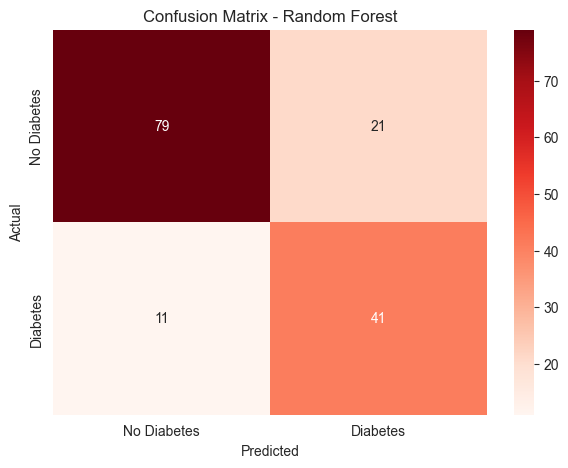

In [47]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

##### **Confusion Matrix Analysis:**
- The model correctly predicted 79 non-diabetic cases (True Negative).

- It incorrectly predicted diabetes for 21 people who are not diabetic (False Positive).

- It missed 11 actual diabetic patients (False Negatives).

- The model correctly identified 41 diabetic cases (True Positive).


In [48]:
# Individual metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf = precision_score(y_test, y_pred_rf_tuned)
recall_rf = recall_score(y_test, y_pred_rf_tuned)
f1_rf = f1_score(y_test, y_pred_rf_tuned)

print(f"\nRandom Forest - Performance Metrics:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")


Random Forest - Performance Metrics:
Accuracy:  0.7895
Precision: 0.6613
Recall:    0.7885
F1-Score:  0.7193


In [49]:
# Classification Report
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf_tuned,
                          target_names=['No Diabetes', 'Diabetes']))



Classification Report - Random Forest:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.79      0.83       100
    Diabetes       0.66      0.79      0.72        52

    accuracy                           0.79       152
   macro avg       0.77      0.79      0.78       152
weighted avg       0.80      0.79      0.79       152



##### **Classification Report Analysis - Random Forest:**

After hyperparameter tuning, the Random Forest model shows balanced performance across both classes:

- Class-wise performance:
  
  * **No Diabetes (0)** → Precision = 88%, Recall = 79%, F1-score = 83%  
  * **Diabetes (1)** → Precision = 66%, Recall = 79%, F1-score = 72%  


- Overall accuracy ~79%, reflecting improved performance compared to the untuned model.  

- The high recall for diabetes indicates the model effectively identifies diabetic patients, which is crucial in medical datasets.  

Overall, the tuned Random Forest generalizes well, maintains balanced class performance, and reliably predicts both diabetic and non-diabetic cases.


### **Feature Importance**
Feature importance shows which medical features (like glucose, BMI, or age) are most important for predicting diabetes. It helps to understand which factors have the biggest impact and also checks that the model is making decisions correctly.




Feature Importance - Random Forest:
                    Feature  Importance
1                   Glucose    0.335535
5                       BMI    0.188994
7                       Age    0.145425
4                   Insulin    0.081031
6  DiabetesPedigreeFunction    0.073787
0               Pregnancies    0.069821
2             BloodPressure    0.056524
3             SkinThickness    0.048884


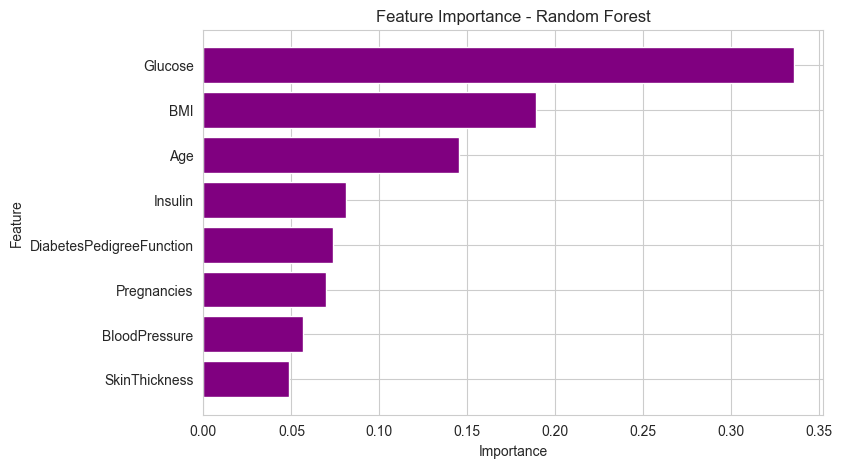

In [50]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_pipeline.named_steps['rf'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance - Random Forest:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='purple')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()  # Highest importance at top
plt.show()

##### **Feature Importance observation:**
- **Glucose** is the most important feature, indicating it has the highest impact on diabetes prediction.
    
- **BMI** and **Age** are also strong contributors, showing that body composition and age significantly affect diabetes risk.

- Other features such as **Insulin**, **BloodPressure**, **Pregnancies**, **SkinThickness**, and **DiabetesPedigreeFunction** have smaller but meaningful effects, helping the model make more accurate predictions.

Therefore, understanding feature importance helps validate the model and shows which factors are most critical for early detection of diabetes.

## 7. MODEL COMPARISON: SVM VS RANDOM FOREST
Comparing best SVM Kernel with random forest by creating comparison table and visualizations to determine which model performs best for diabetes prediction.

#### 7.1 Comparison Table

A comparison table is created to evaluate the performance of the best SVM against the tuned Random Forest model. Metrics such as accuracy, precision, recall, F1-score, and train-test accuracy are included to determine which model performs better for diabetes prediction.


In [51]:
#Comparison table
comparison_models = pd.DataFrame({
    'Model': ['SVM(RBF Kernel)', 'Random Forest'],
    'Accuracy': [accuracy_rbf, accuracy_rf],
    'Precision': [precision_rbf, precision_rf],
    'Recall': [recall_rbf, recall_rf],
    'F1-Score': [f1_rbf, f1_rf],
    'Train Accuracy': [train_score_rbf_tuned, train_score_rf_tuned],
    'Test Accuracy': [test_score_rbf_tuned, test_score_rf_tuned]
})

print("\n" + "="*80)
print("FINAL MODEL COMPARISON: SVM vs RANDOM FOREST")
print("="*80)
print(comparison_models.to_string(index=False))
print("="*80)


FINAL MODEL COMPARISON: SVM vs RANDOM FOREST
          Model  Accuracy  Precision   Recall  F1-Score  Train Accuracy  Test Accuracy
SVM(RBF Kernel)  0.776316    0.65000 0.750000  0.696429        0.807566       0.776316
  Random Forest  0.789474    0.66129 0.788462  0.719298        0.850329       0.789474


#### 7.2 Visual Comparison
A bar chart is created using Matplotlib to compare all metrics side by side. This makes it easy to see which model performs better for diabetes prediction.

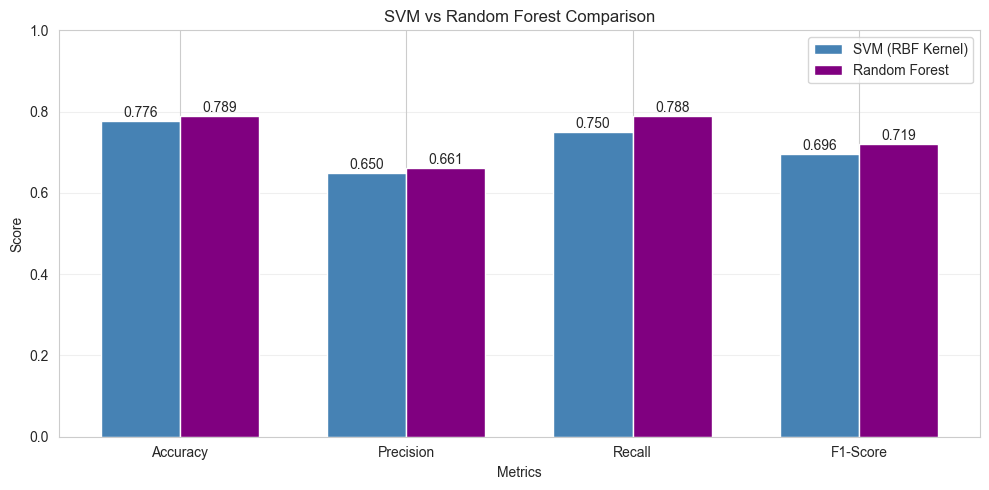

In [52]:
# Metrics and scores
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# metrics
svm_scores = [accuracy_rbf, precision_rbf, recall_rbf, f1_rbf]
rf_scores  = [accuracy_rf, precision_rf, recall_rf, f1_rf]

# X-axis positions
x = np.arange(len(metrics))
width = 0.35

# Plot
plt.figure(figsize=(10,5))
plt.bar(x - width/2, svm_scores, width, label='SVM (RBF Kernel)', color='steelblue')
plt.bar(x + width/2, rf_scores, width, label='Random Forest', color='purple')

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('SVM vs Random Forest Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Adds score labels
for i in range(len(metrics)):
    plt.text(x[i]-width/2, svm_scores[i]+0.01, f'{svm_scores[i]:.3f}', ha='center')
    plt.text(x[i]+width/2, rf_scores[i]+0.01, f'{rf_scores[i]:.3f}', ha='center')

plt.tight_layout()
plt.show()

##### **Model Comparison observation:**

- Both SVM (RBF kernel) and Random Forest achieve similar overall accuracy, with SVM at ~78% and Random Forest slightly higher at ~79%, indicating both models perform well for diabetes prediction.  

- Random Forest has a better balance between precision and recall. Its precision is 66.1% and F1-score 71.9%, slightly higher than SVM's precision (65%) and F1-score (69.6%).  

- Random Forest also achieves higher recall for diabetes (~79% vs 75% for SVM), meaning it correctly identifies more diabetic patients, which is critical in medical datasets.  

- Both models generalize well to unseen data, as indicated by the small gaps between training and testing accuracies (SVM: 80.8% → 77.6%, Random Forest: 85% → 78.9%).  

Overall, Random Forest performs slightly better than SVM, especially in identifying diabetic cases, making it more suitable for this prediction task.

#### 7.3 Confusion Metrics Comparison
The confusion matrices of both models are shown using subplots. This helps us easily see how well each model predicts diabetes, including correct and incorrect predictions, and which model performs better overall.


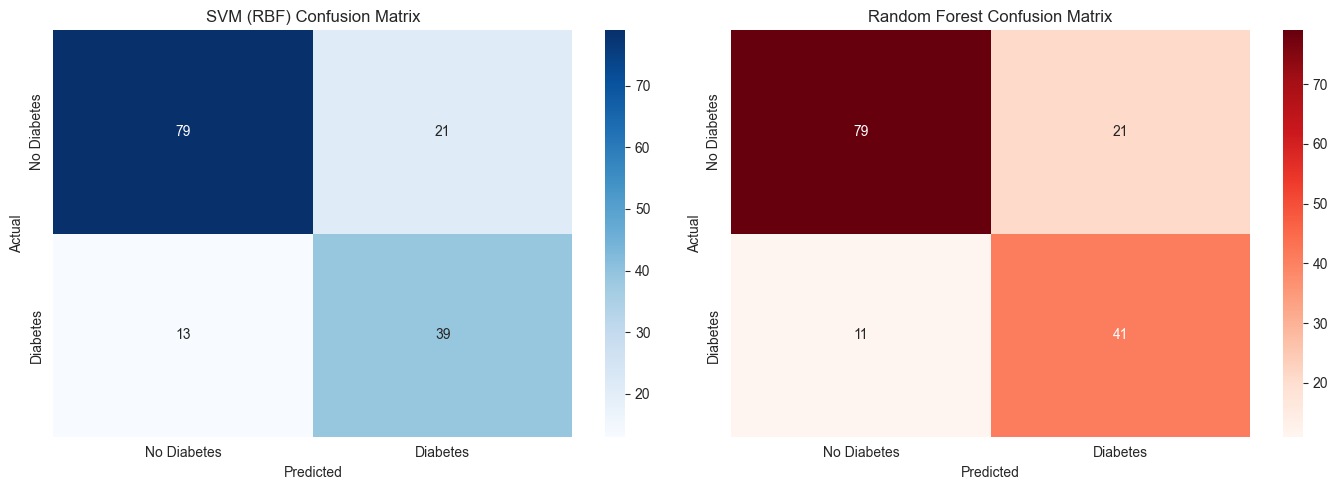

In [53]:
# Compare confusion matrices of SVM (RBF) and Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM (RBF) Confusion Matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf_tuned)
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('SVM (RBF) Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


##### **Confusion Matrix Analyis:**
- Both models correctly predict most non-diabetic cases, with True Negatives being equal for both (79 each).  

- Random Forest identifies more diabetic patients correctly (41 True Positives) than SVM (39 True Positives), making it more effective for medical prediction.  

- SVM misses 13 actual diabetic cases (False Negatives), whereas Random Forest misses only 11, reducing the risk of undetected diabetes.  

- Both models have the same number of false positives (21 False Positives), which is less critical than missing diabetic patients.  

- Overall, Random Forest shows better performance in detecting diabetic cases and maintaining a balanced prediction, making it slightly more reliable than SVM for this dataset.

#### 7.4 ROC-AUC Curve
The ROC-AUC curve show how well a model distinguishes between diabetic and non-diabetic cases.


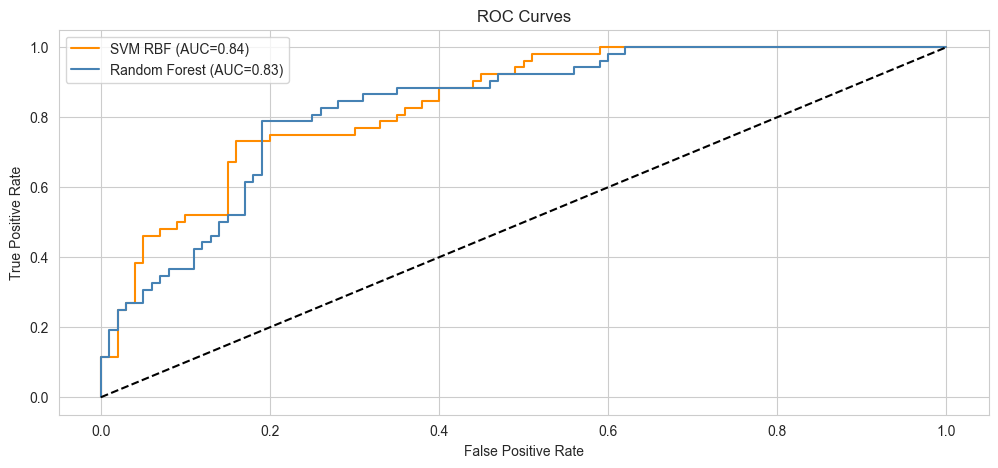

In [54]:
# Calculate ROC curve and AUC for SVM RBF
fpr_svm, tpr_svm, _ = roc_curve(y_test, best_pipe_rbf.decision_function(X_test))
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf_pipeline.predict_proba(X_test)[:,1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot 
plt.figure(figsize=(12,5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM RBF (AUC={roc_auc_svm:.2f})", color='darkorange')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})", color='steelblue')
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

##### **ROC-AUC Curve Observation:**

- Both models perform much better than random guessing, as their ROC curves lie above the diagonal.  

- **SVM RBF (AUC = 0.84):**  
    * It distinguishes between diabetic and non-diabetic cases well.  
    * It has slightly higher AUC, but its balance between precision and recall is lower for diabetic cases.  

- **Random Forest (AUC = 0.83):**  
    * It provides strong class separation with high recall for diabetic patients.  
    * It has slightly lower AUC than SVM, but achieves better F1-score (0.72 vs 0.70), showing a better balance between precision and recall.  

Overall, both models perform well, with Random Forest offering a more balanced class-wise performance despite a slightly lower AUC.

#### 7.5 Learning Curve
The learning curve shows training and validation accuracy as the training set size increases, helping helping evaluate model consistency and generalization.

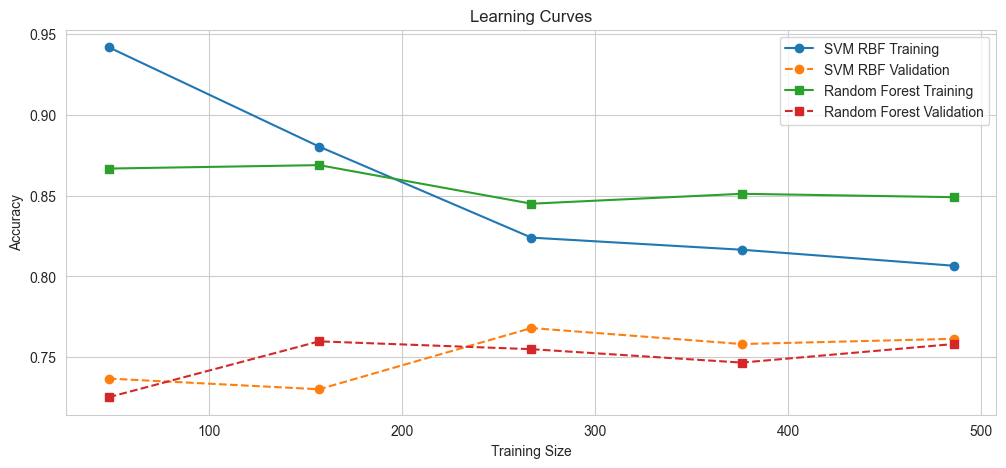

In [58]:
#Learning curve
def plot_learning_curves(model1, model2, X, y, name1="SVM RBF", name2="Random Forest"):
    # Compute learning curves
    train_sizes1, train_scores1, val_scores1 = learning_curve(model1, X, y, cv=5, scoring='accuracy')
    train_sizes2, train_scores2, val_scores2 = learning_curve(model2, X, y, cv=5, scoring='accuracy')

    plt.figure(figsize=(12,5))
    
    # SVM RBF curve
    plt.plot(train_sizes1, np.mean(train_scores1, axis=1), 'o-', label=f"{name1} Training")
    plt.plot(train_sizes1, np.mean(val_scores1, axis=1), 'o--', label=f"{name1} Validation")
    
    # Random Forest curve
    plt.plot(train_sizes2, np.mean(train_scores2, axis=1), 's-', label=f"{name2} Training")
    plt.plot(train_sizes2, np.mean(val_scores2, axis=1), 's--', label=f"{name2} Validation")
    
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(best_pipe_rbf, best_rf_pipeline, X_train, y_train)

##### **Learning Curve Observation:**

- **SVM RBF:**  
    * The training accuracy starts high and gradually stabilizes as more data is added.  
    * The validation accuracy rises and then levels off, showing consistent learning.  
    * The small gap between training and validation curves indicates low overfitting.

- **Random Forest:**  
    * The training accuracy remains high and stable across different training sizes.  
    * The validation accuracy steadily improves and stabilizes, reflecting strong generalization.  
    * The small gap between curves shows the model learns effectively without overfitting.

Overall, both models demonstrate stable learning and good generalization, with Random Forest maintaining slightly more balanced performance across the training and validation sets.


## 8. Selecting the Best Model

The best model is chosen by comparing performance metrics, especially the F1-score, which balances precision and recall. This ensures the model can accurately detect diabetic patients while keeping false positives and false negatives low.


In [56]:
# Select the best model based on F1-score
if f1_rf > f1_rbf: 
    best_model_name = "Random Forest" 
    best_model = best_rf_pipeline 
    best_accuracy = accuracy_rf 
    best_precision = precision_rf
    best_recall = recall_rf
    best_f1 = f1_rf 
else: 
    best_model_name = "SVM (RBF Kernel)"
    best_model = best_pipe_rbf 
    best_accuracy = accuracy_rbf 
    best_precision = precision_rbf
    best_recall = recall_rbf
    best_f1 = f1_rbf
    
# Display best model performance
print("FINAL BEST MODEL SELECTED")
print(f"Model:     {best_model_name}")
print(f"Accuracy:  {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Precision:  {best_precision:.4f} ({best_precision*100:.2f}%)")
print(f"Recall:     {best_recall:.4f} ({best_recall*100:.2f}%)")
print(f"F1-Score:  {best_f1:.4f} ({best_f1*100:.2f}%)")

FINAL BEST MODEL SELECTED
Model:     Random Forest
Accuracy:  0.7895 (78.95%)
Precision:  0.6613 (66.13%)
Recall:     0.7885 (78.85%)
F1-Score:  0.7193 (71.93%)


### Justification for selecting Random Forest as best model
- The Random Forest model is chosen as the best model because it has the highest F1-score (around 72%), which means it balances correctly identifying diabetic patients (recall) and avoiding false alarms (precision) better than SVM.
  
- Its recall for diabetes is high (~79%), so it catches most diabetic cases. This is important because missing a diabetic patient can be risky.  

  
- The difference between training and testing accuracy is small (~3%), showing the model works well on new, unseen data and isn’t overfitting. 
  
- Even though the overall accuracy of SVM(77.6%) and Random Forest(78.9%) is similar, Random Forest gives a more balanced performance, making it more reliable for predicting diabetes.  


Overall, Random Forest is the most dependable and clinically meaningful model for predicting diabetes in this dataset.

# 9. Final Model Comparison & Report

| Model | Test Accuracy | CV Accuracy | Recall (Diabetes) | Winner? |
|-------|---------------|-------------|------------------|---------|
| SVM (RBF Kernel) | ~78% | ~77% | 0.75 | NO |
| **Random Forest** | **~79%** | **~78%** | **~0.79** | **YES** |

After training and evaluation, the models were compared using test accuracy, cross-validation accuracy, recall, F1-score, ROC curves, learning curves, and overall generalization performance.

---

#### 1. RBF SVM vs Polynomial SVM Kernel

Between the two SVM kernels, the **RBF kernel** performed better overall:

- The RBF kernel achieved slightly higher test accuracy (~ 78%) than the Polynomial kernel (75%).  
- It showed better recall for diabetic cases (RBF = 0.75 vs Polynomial = 0.60), meaning it detected more diabetic patients correctly.
- After hyperparameter tuning, the RBF kernel’s training metrics dropped slightly compared to before tuning because it focused on generalization, improving performance on unseen data and to maintain a balanced detection of diabetic cases.
- The RBF kernel generalized better, with a smaller gap between training and testing performance, and handled non-linear patterns effectively.  

Overall, the RBF kernel outperformed the Polynomial kernel, but Random Forest still achieved the best overall performance.

---

#### 2. Why Random Forest is Selected

Random Forest performed best overall, mainly due to its ability to accurately identify diabetic cases:

- It achieved the highest recall (~0.79), detecting more diabetic patients correctly.  
- Test accuracy (78.9%) and training accuracy (85%) show stable generalization with minimal overfitting.  
- It balanced precision (0.66) and recall(~0.79) effectively, making predictions more reliable.  
- Random Forest also provides feature importance, helping interpret which factors are most influential, and requires minimal preprocessing.  

Overall, Random Forest is reliable, interpretable, and clinically meaningful for diabetes prediction.

---

#### 3. Most Important Predictor

**Glucose** was identified as the most important predictor of diabetes:

- It shows the strongest positive correlation with the target variable.  
- It ranks highest in Random Forest feature importance.  
- Medically, high glucose levels are a key indicator of diabetes.  

This confirms glucose as the strongest predictor in the dataset.

---

## Final Conclusion

Based on overall performance, **Random Forest** is the best model for this dataset. It offers strong accuracy, high recall for diabetic cases, balanced precision and recall, and minimal overfitting.  

The SVM RBF kernel performs reasonably well but has slightly lower recall, while the Polynomial SVM shows weaker and less consistent performance.  

Overall, Random Forest is the most dependable choice for predicting diabetes.


### LIMITATIONS AND FUTURE WORK
The dataset is relatively small, so collecting more data could improve model performance. External validation on a different dataset is also needed to ensure real-world reliability.

Future improvements could include exploring advanced models like XGBoost, adding feature engineering, or using ensemble stacking to boost accuracy and recall further.